# Lab 2 — Exploratory Data Analysis
## Cloud Detection in Polar Regions (MISR Satellite Data)

This notebook performs EDA on the 3 labeled MISR images to understand data structure, feature distributions, class separability, and prepare train/validation/test splits.

**Labeled images:** `O013257.npz`, `O013490.npz`, `O012791.npz`

| Column | Feature |
|--------|---------|
| 0 | y coordinate |
| 1 | x coordinate |
| 2 | NDAI |
| 3 | SD |
| 4 | CORR |
| 5 | Radiance DF |
| 6 | Radiance CF |
| 7 | Radiance BF |
| 8 | Radiance AF |
| 9 | Radiance AN |
| 10 | Expert label (+1 cloud, -1 no cloud, 0 unlabeled) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.model_selection import train_test_split
import clean
import feature_engineering
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

FEATURE_COLS = clean.FEATURE_COLS

## 1. Load and Inspect the Data

In [2]:
# Load the 3 labeled images into DataFrames
dfs = clean.read_data()

# Quick look at one image
print("\nSample rows from O013257:")
dfs['O013257'].head()


Sample rows from O013257:


,y,x,NDAI,SD,CORR,Rad_DF,Rad_CF,Rad_BF,Rad_AF,Rad_AN,label
0,2.0,70.0,0.528076,1820.998779,0.900904,22692.50,19834.00,11228.50,8536.50,7008.25,0.0
1,2.0,71.0,0.593831,1169.416504,0.473416,23461.00,18388.50,11575.25,8993.25,5978.75,1.0
2,2.0,72.0,0.550953,1376.460571,0.861363,23831.75,16752.50,12560.25,9570.75,6900.00,1.0
3,2.0,73.0,0.550160,1389.984863,0.687417,23185.75,15590.75,14639.50,8372.50,6728.25,1.0
4,2.0,74.0,0.615813,1388.641357,0.486022,23047.75,16095.25,12771.50,7136.00,5480.00,1.0


In [3]:
# Summary statistics for each image
for name, df in dfs.items():
    print(f"\n{'='*60}")
    print(f"Image: {name}")
    print(f"{'='*60}")
    print(df.describe().round(2))
    
    # Label distribution
    label_counts = df['label'].value_counts().sort_index()
    total = len(df)
    print("\nLabel distribution:")
    for val, count in label_counts.items():
        label_name = {-1: "Not cloud", 0: "Unlabeled", 1: "Cloud"}[int(val)]
        print(f"  {label_name:>12} ({int(val):+d}): {count:>6} ({100*count/total:.1f}%)")


Image: O012791
               y          x       NDAI         SD       CORR     Rad_DF  \
count  114973.00  114973.00  114973.00  114973.00  114973.00  114973.00   
mean      193.00     218.01       0.17     710.09       0.52   25082.13   
std       110.29      86.89       0.08     867.22       0.35    4494.76   
min         2.00      65.00      -0.36      13.33      -0.89    6135.50   
25%        98.00     143.00       0.11      84.20       0.24   22472.50   
50%       193.00     218.00       0.16     359.31       0.59   24756.25   
75%       289.00     293.00       0.21    1022.07       0.83   28185.25   
max       383.00     368.00       0.74    8248.58       0.98   46783.12   

          Rad_CF     Rad_BF     Rad_AF     Rad_AN      label  
count  114973.00  114973.00  114973.00  114973.00  114973.00  
mean    22711.55   20584.80   18920.08   17793.18      -0.11  
std      4031.80    3643.72    3390.78    3191.55       0.68  
min      4477.00    3797.75    3468.75    2997.50      -

In [4]:
# Check for NaN, Inf, and other data quality issues
print("=== Data Quality Checks ===\n")
for name, df in dfs.items():
    print(f"Image: {name}")
    nan_counts = df.isna().sum()
    inf_counts = df.apply(lambda col: np.isinf(col).sum() if col.dtype != 'object' else 0)
    if nan_counts.sum() > 0:
        print(f"  NaN values found:\n{nan_counts[nan_counts > 0]}")
    else:
        print("  No NaN values")
    if inf_counts.sum() > 0:
        print(f"  Inf values found:\n{inf_counts[inf_counts > 0]}")
    else:
        print("  No Inf values")
    
    # Check for duplicate (y, x) coordinates
    n_dupes = df.duplicated(subset=['y', 'x']).sum()
    print(f"  Duplicate (y, x) coords: {n_dupes}")
    
    # Check for zero-variance features
    near_zero = df[clean.FEATURE_COLS].std()
    print(f"  Feature std range: [{near_zero.min():.4f}, {near_zero.max():.2f}]")
    print()

=== Data Quality Checks ===

Image: O012791
  No NaN values
  No Inf values
  Duplicate (y, x) coords: 0
  Feature std range: [0.0847, 4494.76]

Image: O013257
  No NaN values
  No Inf values
  Duplicate (y, x) coords: 0
  Feature std range: [0.0749, 4748.70]

Image: O013490
  No NaN values
  No Inf values
  Duplicate (y, x) coords: 0
  Feature std range: [0.1123, 4365.19]



## 2. Cloud Maps — Spatial Distribution of Expert Labels

Plot the expert labels on the (x, y) grid for each image. This shows the spatial structure of clouds and clear regions.

- **Blue** = Not Cloud (-1)
- **Gray** = Unlabeled (0) 
- **Red** = Cloud (+1)

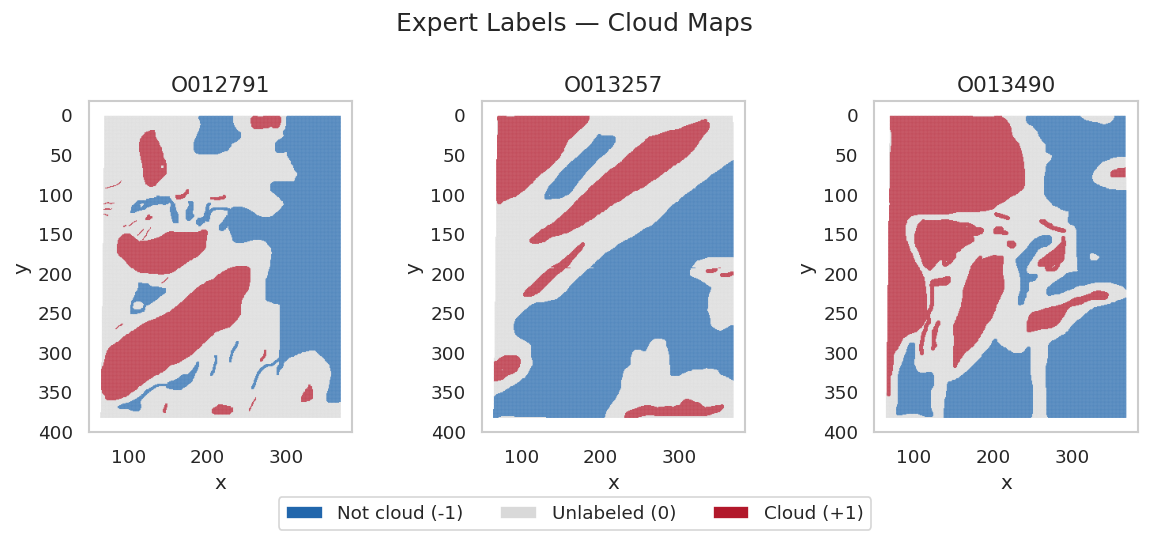

In [5]:
from matplotlib.patches import Patch
# Plot expert labels as spatial cloud maps
cmap = mcolors.ListedColormap(['#2166ac', '#d9d9d9', '#b2182b'])
bounds = [-1.5, -0.5, 0.5, 1.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, (name, df) in zip(axes, dfs.items()):
    sc = ax.scatter(df['x'], df['y'], c=df['label'], cmap=cmap, norm=norm,
                    s=0.3, edgecolors='none')
    ax.set_title(f'{name}', fontsize=13)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.grid(False)

# Shared legend
legend_elements = [Patch(facecolor='#2166ac', label='Not cloud (-1)'),
                   Patch(facecolor='#d9d9d9', label='Unlabeled (0)'),
                   Patch(facecolor='#b2182b', label='Cloud (+1)')]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.08))
fig.suptitle('Expert Labels — Cloud Maps', fontsize=15, y=1.02)
plt.tight_layout()
#plt.savefig('../report/figures/image_label_plots', bbox_inches='tight')
plt.show()

## 3. Data Cleaning

A thorough data cleaning pipeline to ensure data quality before modeling:

1. **Remove unlabeled pixels** (label = 0) — only labeled data for supervised analysis
2. **Detect missing / invalid values** — NaN, Inf, negative radiance, out-of-range CORR
3. **Identify outliers** — IQR-based flagging and z-score analysis per feature
4. **Treat outliers** — Winsorize extreme values to reduce their influence
5. **Before vs After comparison** — verify cleaning preserved data integrity

In [6]:
### Step 3.1: Remove unlabeled pixels (label == 0)
# Keep only cloud (+1) and not-cloud (-1) for supervised analysis

dfs_labeled = clean.remove_unlabeled(dfs, verbose=True)

O012791: 114973 -> 54772 pixels (removed 60201 unlabeled, 52.4%)
  Cloud: 21244 (38.8%), Not cloud: 33528 (61.2%)
O013257: 115000 -> 70826 pixels (removed 44174 unlabeled, 38.4%)
  Cloud: 20468 (28.9%), Not cloud: 50358 (71.1%)
O013490: 115032 -> 82083 pixels (removed 32949 unlabeled, 28.6%)
  Cloud: 39253 (47.8%), Not cloud: 42830 (52.2%)


In [7]:
### Step 3.2: Detect missing and invalid values in labeled data
print("=== Missing / Invalid Value Audit (labeled pixels only) ===\n")

all_labeled_raw = clean.combine_labeled(dfs_labeled)

# (a) NaN check
nan_per_feat = all_labeled_raw[FEATURE_COLS].isna().sum()
print(f"NaN counts per feature:\n{nan_per_feat.to_string()}\n")

# (b) Inf check
inf_per_feat = all_labeled_raw[FEATURE_COLS].apply(lambda c: np.isinf(c).sum())
print(f"Inf counts per feature:\n{inf_per_feat.to_string()}\n")

# (c) Negative radiance values (physically impossible — radiance must be >= 0)
radiance_feats = ['Rad_DF', 'Rad_CF', 'Rad_BF', 'Rad_AF', 'Rad_AN']
neg_counts = {}
for feat in radiance_feats:
    n_neg = (all_labeled_raw[feat] < 0).sum()
    neg_counts[feat] = n_neg
neg_series = pd.Series(neg_counts, name='Negative count')
print(f"Negative radiance values (physically invalid):\n{neg_series.to_string()}\n")

# (d) CORR out of range [-1, 1] (correlation should be bounded)
n_corr_out = ((all_labeled_raw['CORR'] < -1) | (all_labeled_raw['CORR'] > 1)).sum()
print(f"CORR values outside [-1, 1]: {n_corr_out}")

# (e) Duplicate coordinate check within each image
print("\nDuplicate (y, x) coordinates per image:")
for name, df in dfs_labeled.items():
    n_dupes = df.duplicated(subset=['y', 'x']).sum()
    print(f"  {name}: {n_dupes} duplicates")

# (f) Zero / constant rows (all features identical — suspicious)
feature_std_per_row = all_labeled_raw[FEATURE_COLS].std(axis=1)
n_constant = (feature_std_per_row == 0).sum()
print(f"\nRows with zero variance across all features (constant rows): {n_constant}")

=== Missing / Invalid Value Audit (labeled pixels only) ===

NaN counts per feature:
NDAI      0
SD        0
CORR      0
Rad_DF    0
Rad_CF    0
Rad_BF    0
Rad_AF    0
Rad_AN    0

Inf counts per feature:
NDAI      0
SD        0
CORR      0
Rad_DF    0
Rad_CF    0
Rad_BF    0
Rad_AF    0
Rad_AN    0

Negative radiance values (physically invalid):
Rad_DF    0
Rad_CF    0
Rad_BF    0
Rad_AF    0
Rad_AN    0

CORR values outside [-1, 1]: 0

Duplicate (y, x) coordinates per image:
  O012791: 0 duplicates
  O013257: 0 duplicates
  O013490: 0 duplicates

Rows with zero variance across all features (constant rows): 0


In [8]:
### Step 3.3: Feature range summary + outlier detection (IQR method)
print("=== Feature Range Summary & IQR-Based Outlier Detection ===\n")

outlier_summary = []
for feat in FEATURE_COLS:
    col = all_labeled_raw[feat]
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_below = (col < lower).sum()
    n_above = (col > upper).sum()
    n_outliers = n_below + n_above
    pct_outliers = 100 * n_outliers / len(col)
    outlier_summary.append({
        'Feature': feat,
        'Min': col.min(),
        'Q1': q1,
        'Median': col.median(),
        'Q3': q3,
        'Max': col.max(),
        'IQR': iqr,
        'Lower fence': lower,
        'Upper fence': upper,
        'N below': n_below,
        'N above': n_above,
        'N outliers': n_outliers,
        '% outliers': round(pct_outliers, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df[['Feature', 'Min', 'Q1', 'Median', 'Q3', 'Max']].to_string(index=False))
print()
print(outlier_df[['Feature', 'Lower fence', 'Upper fence', 'N below', 'N above', 'N outliers', '% outliers']].to_string(index=False))
print()
print(f"Total labeled pixels: {len(all_labeled_raw):,}")
print(f"Features with >5% outliers: {(outlier_df['% outliers'] > 5).sum()}")

=== Feature Range Summary & IQR-Based Outlier Detection ===

Feature         Min           Q1       Median           Q3          Max
   NDAI   -0.348311     0.126360     0.155215     0.225420     0.816864
     SD   13.329613    36.700203   125.152588   540.893127  7251.009277
   CORR   -0.942551     0.067111     0.391179     0.768725     0.982818
 Rad_DF 4904.000000 25267.250000 28623.000000 30238.000000 51807.125000
 Rad_CF 3536.750000 22443.000000 26521.750000 28419.250000 35866.000000
 Rad_BF 2841.250000 20194.750000 24070.750000 26113.250000 31653.750000
 Rad_AF 2544.750000 18875.250000 21668.000000 23944.000000 30348.750000
 Rad_AN 2528.750000 17829.250000 20102.750000 21894.250000 29540.000000

Feature  Lower fence  Upper fence  N below  N above  N outliers  % outliers
   NDAI    -0.022231     0.374011      190    15163       15353        7.39
     SD  -719.589184  1297.182514        0    12898       12898        6.21
   CORR    -0.985309     1.821145        0        0           

In [9]:
### Step 3.4: Z-score analysis — identify extreme outliers (|z| > 5)
from scipy import stats

print("=== Extreme Outlier Detection (|z-score| > 5) ===\n")

zscore_summary = []
for feat in FEATURE_COLS:
    col = all_labeled_raw[feat]
    z = np.abs(stats.zscore(col, nan_policy='omit'))
    z = pd.Series(z, index=col.index)
    n_extreme = (z > 5).sum()
    max_z = z.max()
    zscore_summary.append({
        'Feature': feat,
        '|z| > 3': (z > 3).sum(),
        '|z| > 5': n_extreme,
        '|z| > 10': (z > 10).sum(),
        'Max |z|': round(max_z, 1),
    })

zscore_df = pd.DataFrame(zscore_summary)
print(zscore_df.to_string(index=False))
print()

# Show the most extreme values for each feature
print("Top 3 most extreme values per feature:")
for feat in FEATURE_COLS:
    col = all_labeled_raw[feat]
    z = np.abs(stats.zscore(col, nan_policy='omit'))
    z = pd.Series(z, index=col.index)
    top_idx = z.nlargest(3).index
    vals = col.loc[top_idx].values
    z_vals = z.loc[top_idx].values
    print(f"  {feat:>8}: values = {np.round(vals, 2)}, z-scores = {np.round(z_vals, 1)}")

=== Extreme Outlier Detection (|z-score| > 5) ===

Feature  |z| > 3  |z| > 5  |z| > 10  Max |z|
   NDAI     4626      109         0      6.0
     SD     4253     1143        12     12.5
   CORR      134        0         0      3.2
 Rad_DF     2344       59         0      5.7
 Rad_CF     3309       16         0      5.2
 Rad_BF     3164        0         0      4.6
 Rad_AF     3061        0         0      4.2
 Rad_AN     3446        0         0      4.1

Top 3 most extreme values per feature:
      NDAI: values = [0.14 0.44 0.82 0.21 0.8  0.36 0.79], z-scores = [0.5 2.4 6.  0.1 5.9 1.6 5.8]
        SD: values = [7251.01 3186.39 1426.27 4821.76 6563.52 1513.04 6516.28  445.12], z-scores = [12.5  5.1  1.9  8.1 11.2  2.1 11.1  0.1]
      CORR: values = [-0.94 -0.04 -0.94 -0.05 -0.94  0.09], z-scores = [3.2 1.  3.2 1.1 3.2 0.7]
    Rad_DF: values = [22080.25 51807.12 50523.19 22338.25 28977.   50460.44], z-scores = [1.3 5.7 5.4 1.3 0.3 5.3]
    Rad_CF: values = [13678.75  3536.75 13400.25  3

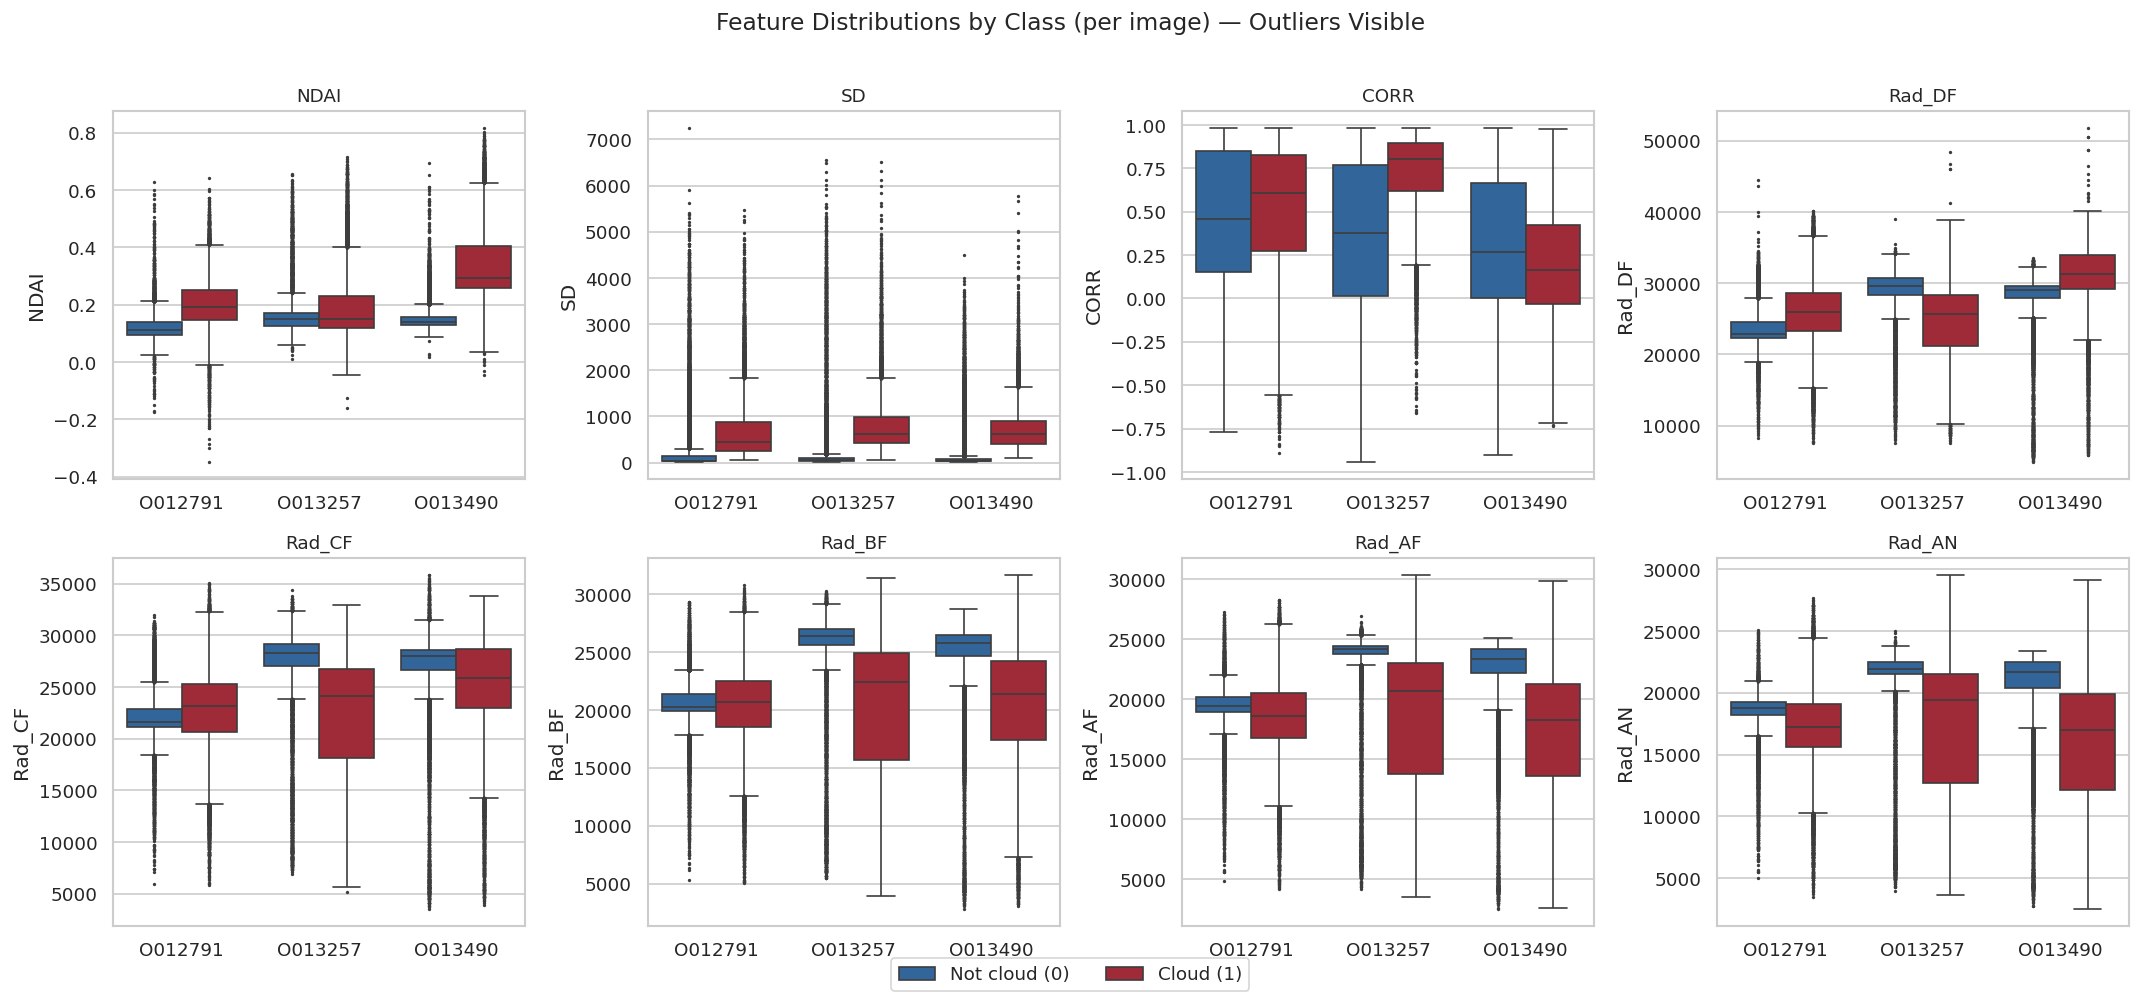

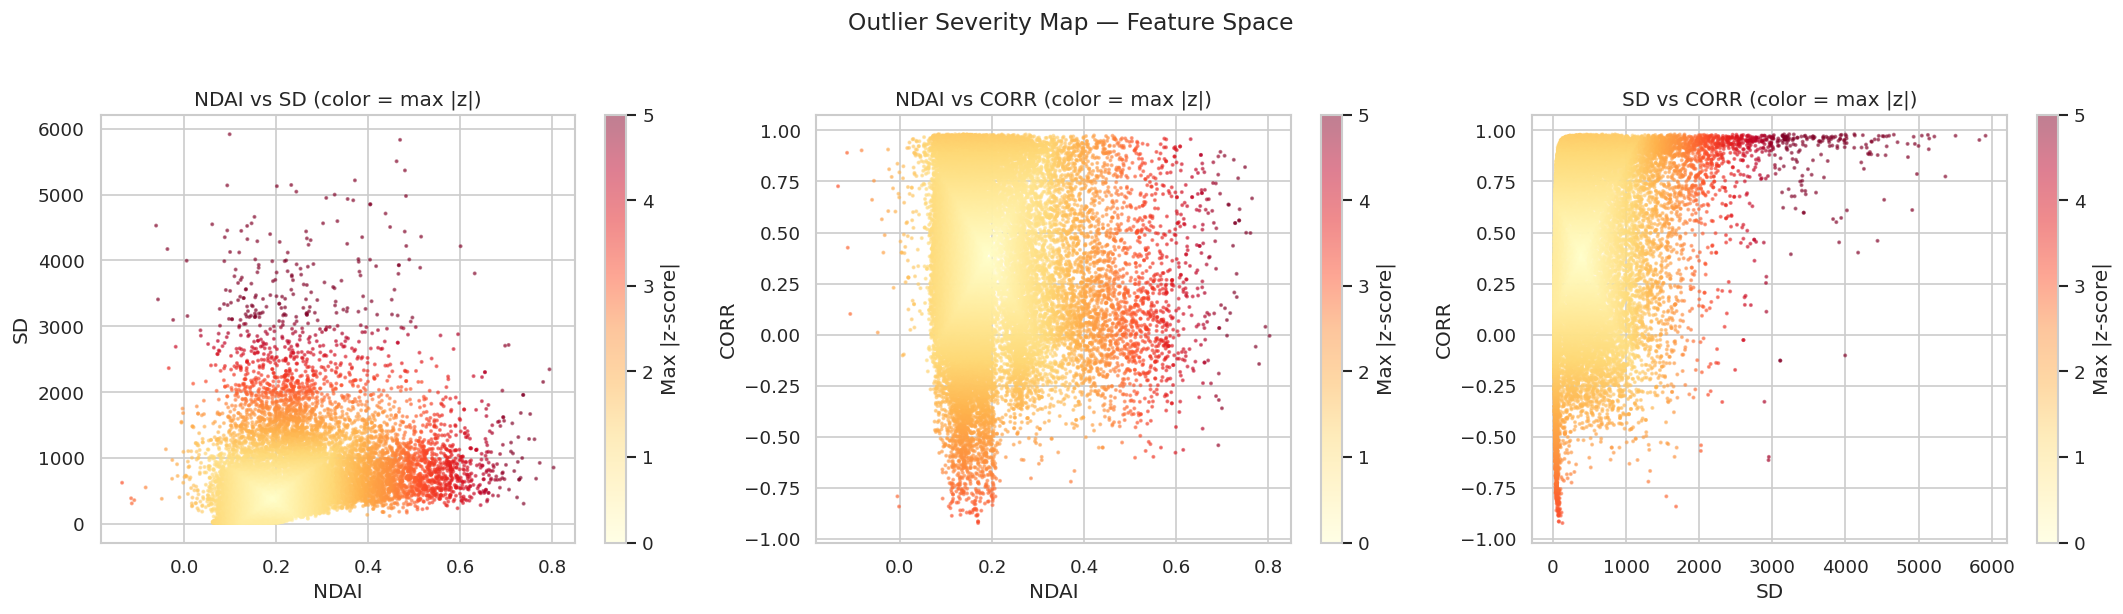

In [10]:
### Step 3.5: Visualize outliers — boxplots + scatter highlighting
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, feat in zip(axes.flat, FEATURE_COLS):
    sns.boxplot(data=all_labeled_raw, x='image', y=feat, hue='cloud',
                ax=ax, palette={0: '#2166ac', 1: '#b2182b'}, fliersize=1)
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel('')
    ax.legend([], [], frameon=False)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, ['Not cloud (0)', 'Cloud (1)'], loc='lower center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Feature Distributions by Class (per image) — Outliers Visible', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Highlight extreme outliers in scatter plots colored by z-score magnitude
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat_pair in zip(axes, [('NDAI', 'SD'), ('NDAI', 'CORR'), ('SD', 'CORR')]):
    f1, f2 = feat_pair
    z1 = pd.Series(np.abs(stats.zscore(all_labeled_raw[f1], nan_policy='omit')),
                   index=all_labeled_raw.index)
    z2 = pd.Series(np.abs(stats.zscore(all_labeled_raw[f2], nan_policy='omit')),
                   index=all_labeled_raw.index)
    max_z = np.maximum(z1, z2)
    
    # Sample for visibility
    sample_idx = all_labeled_raw.sample(n=min(15000, len(all_labeled_raw)), random_state=42).index
    
    sc = ax.scatter(all_labeled_raw.loc[sample_idx, f1], 
                    all_labeled_raw.loc[sample_idx, f2],
                    c=max_z.loc[sample_idx], cmap='YlOrRd', s=2, alpha=0.5,
                    vmin=0, vmax=5)
    ax.set_xlabel(f1)
    ax.set_ylabel(f2)
    ax.set_title(f'{f1} vs {f2} (color = max |z|)')
    plt.colorbar(sc, ax=ax, label='Max |z-score|')

fig.suptitle('Outlier Severity Map — Feature Space', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
### Step 3.6: Outlier treatment — Winsorize extreme values
# Strategy: clip features at 1st and 99th percentiles to reduce influence of
# extreme outliers while preserving the overall distribution shape.
# We do NOT remove rows — just cap extreme values.

print("=== Outlier Treatment: Winsorization (1st–99th percentile clipping) ===\n")

dfs_labeled = clean.winsorize(dfs_labeled, verbose=True)

print("\nWinsorization complete.")

=== Outlier Treatment: Winsorization (1st–99th percentile clipping) ===

  O012791 |     NDAI: clipped 1096 values to [0.045, 0.386]
  O012791 |       SD: clipped 1096 values to [19.701, 2966.179]
  O012791 |     CORR: clipped 1096 values to [-0.372, 0.968]
  O012791 |   Rad_DF: clipped 1096 values to [14658.558, 35144.113]
  O012791 |   Rad_CF: clipped 1096 values to [12558.282, 30183.805]
  O012791 |   Rad_BF: clipped 1096 values to [11062.090, 26854.410]
  O012791 |   Rad_AF: clipped 1096 values to [9830.890, 25053.007]
  O012791 |   Rad_AN: clipped 1096 values to [9079.138, 23766.193]
  O013257 |     NDAI: clipped 1418 values to [0.071, 0.481]
  O013257 |       SD: clipped 1418 values to [22.628, 3008.988]
  O013257 |     CORR: clipped 1418 values to [-0.656, 0.971]
  O013257 |   Rad_DF: clipped 1418 values to [14160.938, 32659.312]
  O013257 |   Rad_CF: clipped 1418 values to [10903.688, 31126.188]
  O013257 |   Rad_BF: clipped 1418 values to [8452.688, 28477.188]
  O013257 |   Ra

=== Before vs After Cleaning Comparison ===

Feature  Before min  After min  Before max  After max  Before std  After std  Before mean  After mean
   NDAI      -0.348      0.045       0.817      0.617       0.105      0.102        0.190       0.190
     SD      13.330     19.701    7251.009   3008.988     551.219    515.772      382.072     375.655
   CORR      -0.943     -0.656       0.983      0.971       0.409      0.406        0.385       0.386
 Rad_DF    4904.000  14160.938   51807.125  35871.750    4261.442   4124.083    27667.507   27690.686
 Rad_CF    3536.750  10903.688   35866.000  31126.188    4193.657   4091.043    25246.600   25262.240
 Rad_BF    2841.250   7771.185   31653.750  28477.188    4312.250   4246.258    22708.126   22718.839
 Rad_AF    2544.750   5741.205   30348.750  25641.438    4302.098   4254.921    20511.899   20516.174
 Rad_AN    2528.750   5295.955   29540.000  23856.250    4021.090   3978.027    19031.444   19032.925


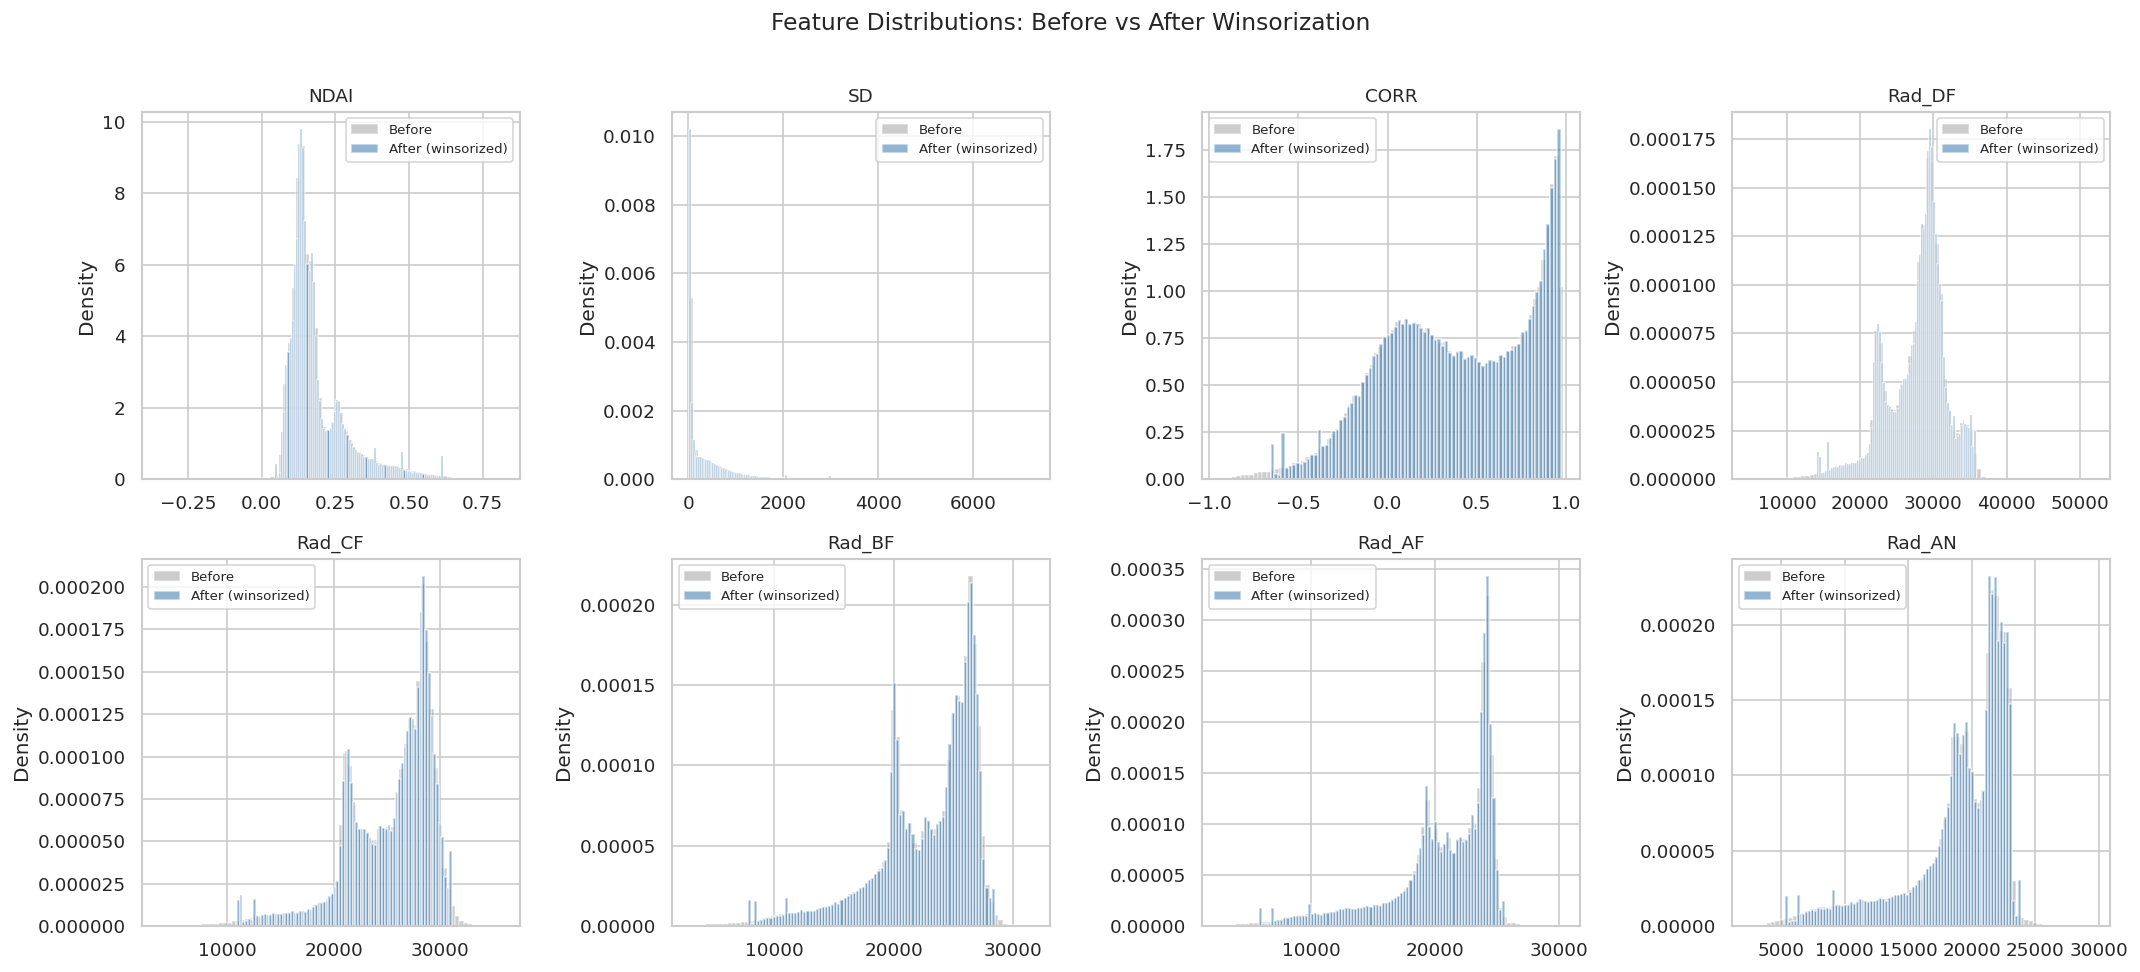


Class balance (after cleaning):
  Cloud:      80965 (39.0%)
  Not cloud: 126716 (61.0%)
  Total:     207681

Data shape preserved: 207681 == 207681 → True


In [12]:
### Step 3.7: Before vs After — compare distributions after cleaning
# Rebuild the pooled dataframe from cleaned per-image data
all_labeled = clean.combine_labeled(dfs_labeled)

print("=== Before vs After Cleaning Comparison ===\n")

comparison = []
for feat in FEATURE_COLS:
    before = all_labeled_raw[feat]
    after = all_labeled[feat]
    comparison.append({
        'Feature': feat,
        'Before min': round(before.min(), 3),
        'After min': round(after.min(), 3),
        'Before max': round(before.max(), 3),
        'After max': round(after.max(), 3),
        'Before std': round(before.std(), 3),
        'After std': round(after.std(), 3),
        'Before mean': round(before.mean(), 3),
        'After mean': round(after.mean(), 3),
    })
comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))

# Visual comparison: overlay before/after histograms for features with most change
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, feat in zip(axes.flat, FEATURE_COLS):
    ax.hist(all_labeled_raw[feat], bins=80, alpha=0.4, color='gray', 
            label='Before', density=True)
    ax.hist(all_labeled[feat], bins=80, alpha=0.6, color='steelblue', 
            label='After (winsorized)', density=True)
    ax.set_title(feat, fontsize=11)
    ax.legend(fontsize=8)
    ax.set_ylabel('Density')

fig.suptitle('Feature Distributions: Before vs After Winsorization', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Verify class balance unchanged
print("\nClass balance (after cleaning):")
print(f"  Cloud:     {all_labeled['cloud'].sum():>6} ({100*all_labeled['cloud'].mean():.1f}%)")
print(f"  Not cloud: {(all_labeled['cloud']==0).sum():>6} ({100*(1-all_labeled['cloud'].mean()):.1f}%)")
print(f"  Total:     {len(all_labeled):>6}")
print(f"\nData shape preserved: {len(all_labeled)} == {len(all_labeled_raw)} → {len(all_labeled) == len(all_labeled_raw)}")

In [13]:
### Step 3.8: Per-image cleaning summary + class distribution after cleaning
print("=== Final Cleaning Summary Per Image ===\n")

for name, df in dfs_labeled.items():
    print(f"Image: {name}")
    print(f"  Labeled pixels: {len(df):,}")
    print(f"  Cloud: {df['cloud'].sum():,} ({100*df['cloud'].mean():.1f}%)")
    print(f"  Not cloud: {(df['cloud']==0).sum():,} ({100*(1-df['cloud'].mean()):.1f}%)")
    # Check if any NaN/Inf were introduced
    n_nan = df[FEATURE_COLS].isna().sum().sum()
    n_inf = df[FEATURE_COLS].apply(lambda c: np.isinf(c).sum()).sum()
    print(f"  NaN after cleaning: {n_nan}, Inf after cleaning: {n_inf}")
    # Feature ranges
    for feat in FEATURE_COLS:
        print(f"    {feat:>8}: [{df[feat].min():.3f}, {df[feat].max():.3f}]  "
              f"mean={df[feat].mean():.3f}, std={df[feat].std():.3f}")
    print()

=== Final Cleaning Summary Per Image ===

Image: O012791
  Labeled pixels: 54,772
  Cloud: 21,244 (38.8%)
  Not cloud: 33,528 (61.2%)
  NaN after cleaning: 0, Inf after cleaning: 0
        NDAI: [0.045, 0.386]  mean=0.152, std=0.071
          SD: [19.701, 2966.179]  mean=391.641, std=580.986
        CORR: [-0.372, 0.968]  mean=0.487, std=0.365
      Rad_DF: [14658.558, 35144.113]  mean=24531.515, std=3661.872
      Rad_CF: [12558.282, 30183.805]  mean=22389.982, std=2970.227
      Rad_BF: [11062.090, 26854.410]  mean=20505.094, std=2563.289
      Rad_AF: [9830.890, 25053.007]  mean=19049.233, std=2424.213
      Rad_AN: [9079.138, 23766.193]  mean=18005.031, std=2326.318

Image: O013257
  Labeled pixels: 70,826
  Cloud: 20,468 (28.9%)
  Not cloud: 50,358 (71.1%)
  NaN after cleaning: 0, Inf after cleaning: 0
        NDAI: [0.071, 0.481]  mean=0.162, std=0.070
          SD: [22.628, 3008.988]  mean=327.622, std=526.840
        CORR: [-0.656, 0.971]  mean=0.460, std=0.429
      Rad_DF: [1

## 4. Feature Exploration — Expert Features (NDAI, SD, CORR)

These three features were engineered by domain experts. Let's examine how well they separate cloud from non-cloud pixels.

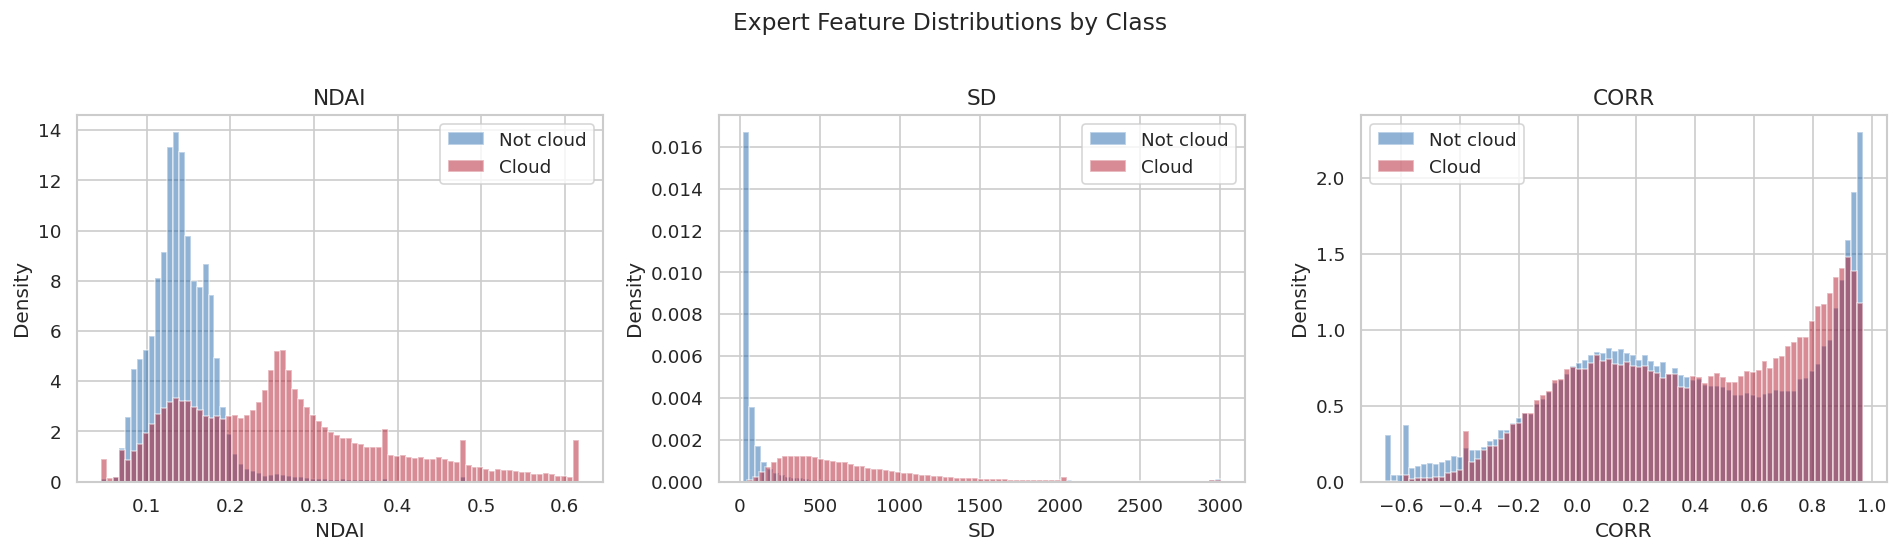

In [14]:
# Histograms of expert features by class (pooled across all 3 images)
expert_feats = ['NDAI', 'SD', 'CORR']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, feat in zip(axes, expert_feats):
    for cls, color, label in [(0, '#2166ac', 'Not cloud'), (1, '#b2182b', 'Cloud')]:
        subset = all_labeled[all_labeled['cloud'] == cls][feat]
        ax.hist(subset, bins=80, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(feat, fontsize=13)
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend()

fig.suptitle('Expert Feature Distributions by Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

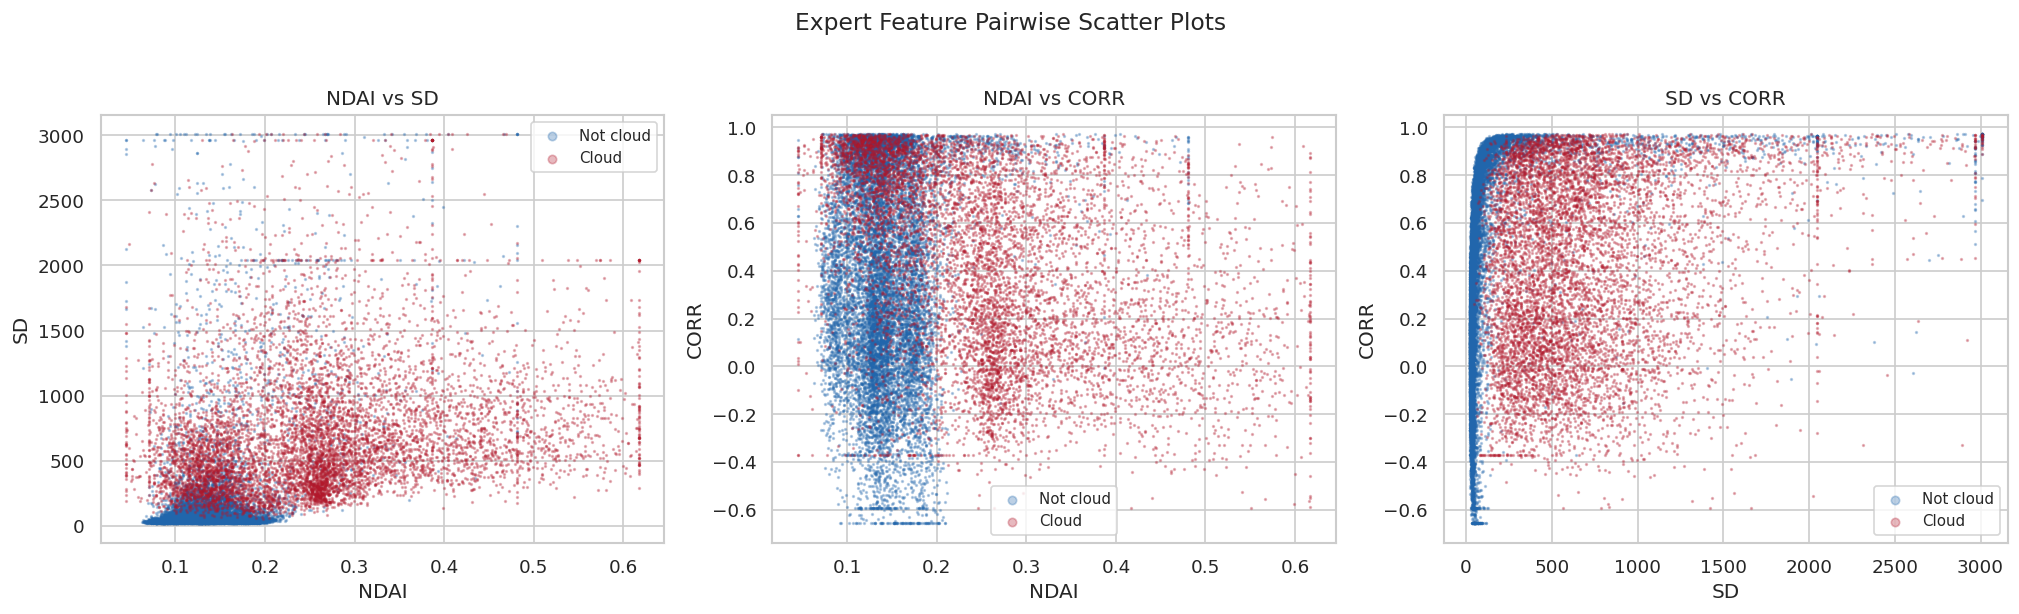

In [15]:
# Pairwise scatter plots of expert features, colored by class
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
pairs = [('NDAI', 'SD'), ('NDAI', 'CORR'), ('SD', 'CORR')]

# Subsample for faster plotting
sample = all_labeled.sample(n=min(20000, len(all_labeled)), random_state=42)

for ax, (f1, f2) in zip(axes, pairs):
    for cls, color, label in [(0, '#2166ac', 'Not cloud'), (1, '#b2182b', 'Cloud')]:
        sub = sample[sample['cloud'] == cls]
        ax.scatter(sub[f1], sub[f2], c=color, s=1, alpha=0.3, label=label)
    ax.set_xlabel(f1)
    ax.set_ylabel(f2)
    ax.set_title(f'{f1} vs {f2}')
    ax.legend(markerscale=5, fontsize=9)

fig.suptitle('Expert Feature Pairwise Scatter Plots', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Feature Exploration — Radiance Angles

Explore the 5 radiance angles (DF, CF, BF, AF, AN) and their relationships between classes.

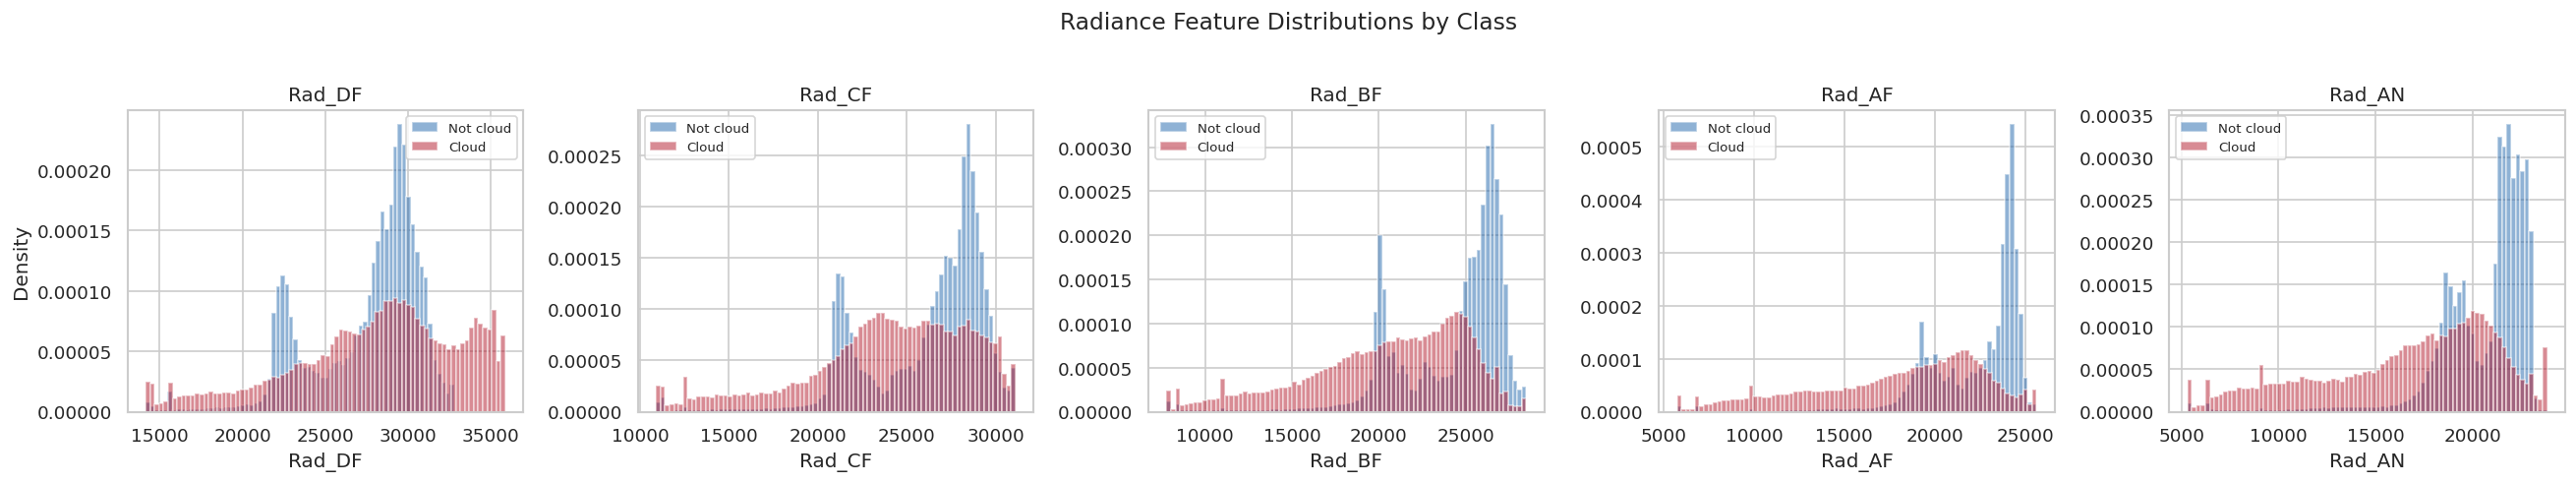

In [16]:
# Histograms of radiance features by class
radiance_feats = ['Rad_DF', 'Rad_CF', 'Rad_BF', 'Rad_AF', 'Rad_AN']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, feat in zip(axes, radiance_feats):
    for cls, color, label in [(0, '#2166ac', 'Not cloud'), (1, '#b2182b', 'Cloud')]:
        subset = all_labeled[all_labeled['cloud'] == cls][feat]
        ax.hist(subset, bins=80, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(feat, fontsize=12)
    ax.set_xlabel(feat)
    if ax == axes[0]:
        ax.set_ylabel('Density')
    ax.legend(fontsize=8)

fig.suptitle('Radiance Feature Distributions by Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

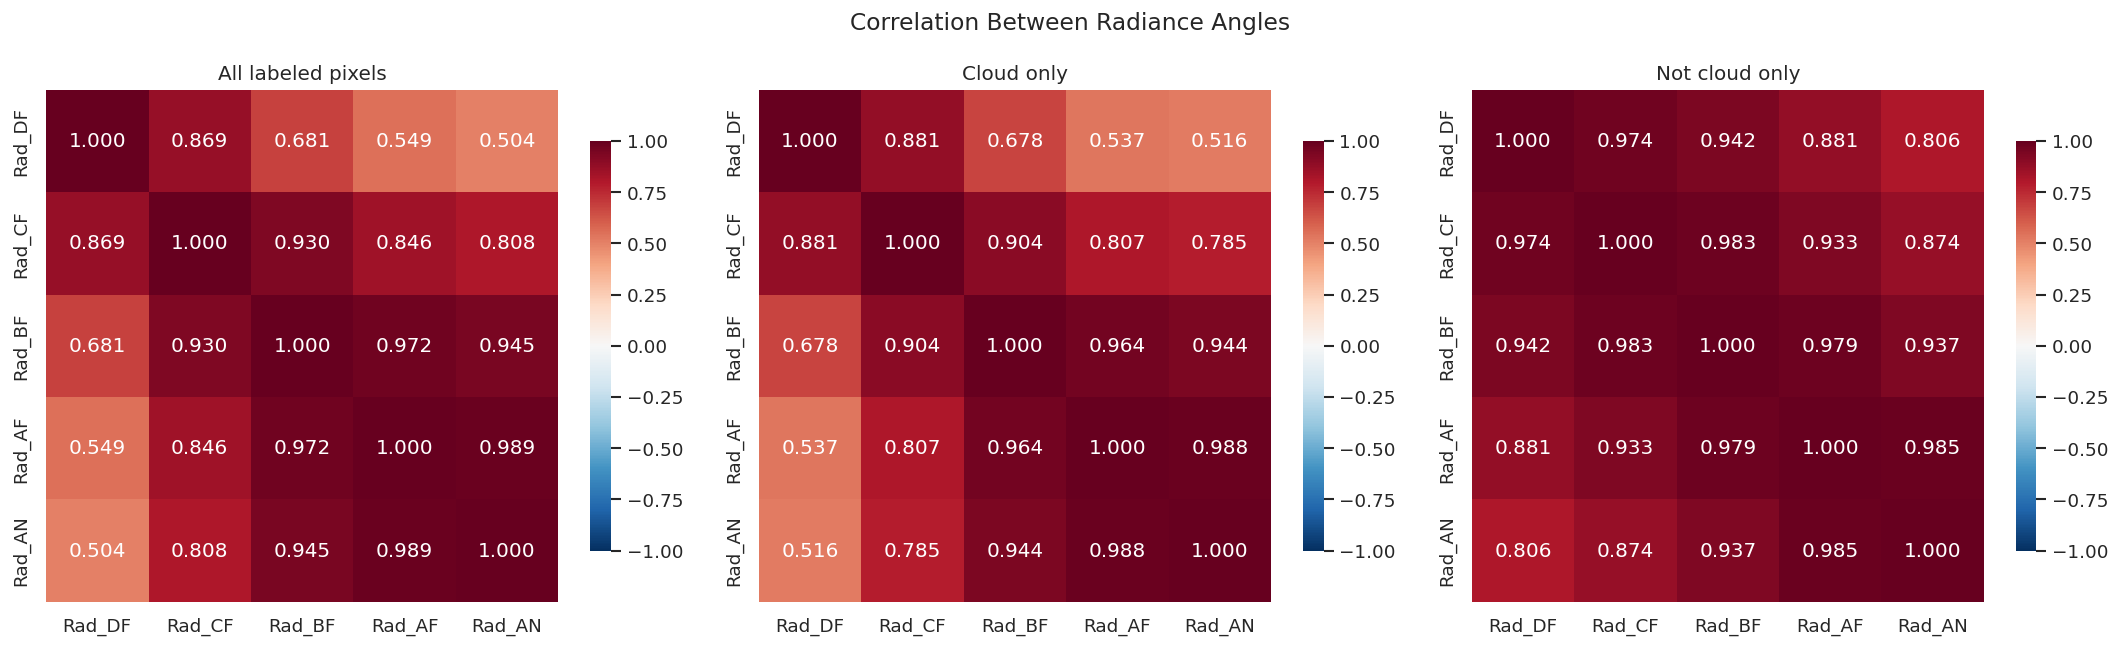

In [17]:
# Correlation heatmap of radiance angles — overall and per class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, subset) in zip(axes, [
    ('All labeled pixels', all_labeled[radiance_feats]),
    ('Cloud only', all_labeled[all_labeled['cloud'] == 1][radiance_feats]),
    ('Not cloud only', all_labeled[all_labeled['cloud'] == 0][radiance_feats]),
]):
    corr = subset.corr()
    sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', vmin=-1, vmax=1,
                ax=ax, square=True, cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=12)

fig.suptitle('Correlation Between Radiance Angles', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Correlation of All Features with Cloud Label

Quantify how well each feature separates the two classes using correlation with the label and the absolute mean difference between classes.

Feature Discriminative Power (sorted by standardized mean difference):

Feature  Corr with cloud  |Standardized Δ|
   NDAI         0.577464          1.184013
     SD         0.529466          1.085599
 Rad_AF        -0.496631          1.018274
 Rad_AN        -0.495650          1.016263
 Rad_BF        -0.436222          0.894415
 Rad_CF        -0.260136          0.533375
 Rad_DF         0.062673          0.128503
   CORR         0.055583          0.113966


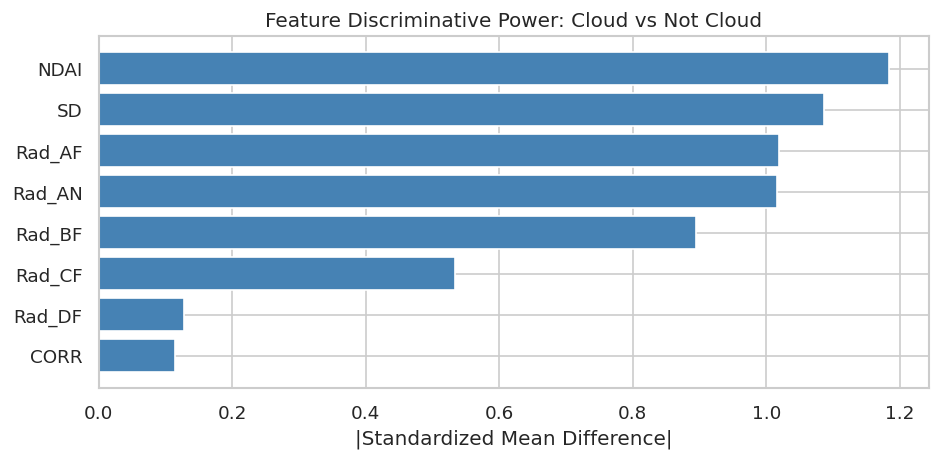

In [18]:
# Feature importance: correlation with class label + standardized mean difference
cloud = all_labeled[all_labeled['cloud'] == 1]
no_cloud = all_labeled[all_labeled['cloud'] == 0]

importance = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Corr with cloud': [all_labeled[f].corr(all_labeled['cloud']) for f in FEATURE_COLS],
    'Mean (cloud)': [cloud[f].mean() for f in FEATURE_COLS],
    'Mean (not cloud)': [no_cloud[f].mean() for f in FEATURE_COLS],
    'Std (pooled)': [all_labeled[f].std() for f in FEATURE_COLS],
})
importance['|Standardized Δ|'] = abs(importance['Mean (cloud)'] - importance['Mean (not cloud)']) / importance['Std (pooled)']
importance = importance.sort_values('|Standardized Δ|', ascending=False)

print("Feature Discriminative Power (sorted by standardized mean difference):\n")
print(importance[['Feature', 'Corr with cloud', '|Standardized Δ|']].to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance['Feature'], importance['|Standardized Δ|'], color='steelblue')
ax.set_xlabel('|Standardized Mean Difference|')
ax.set_title('Feature Discriminative Power: Cloud vs Not Cloud')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Full Correlation Matrix (All Features)

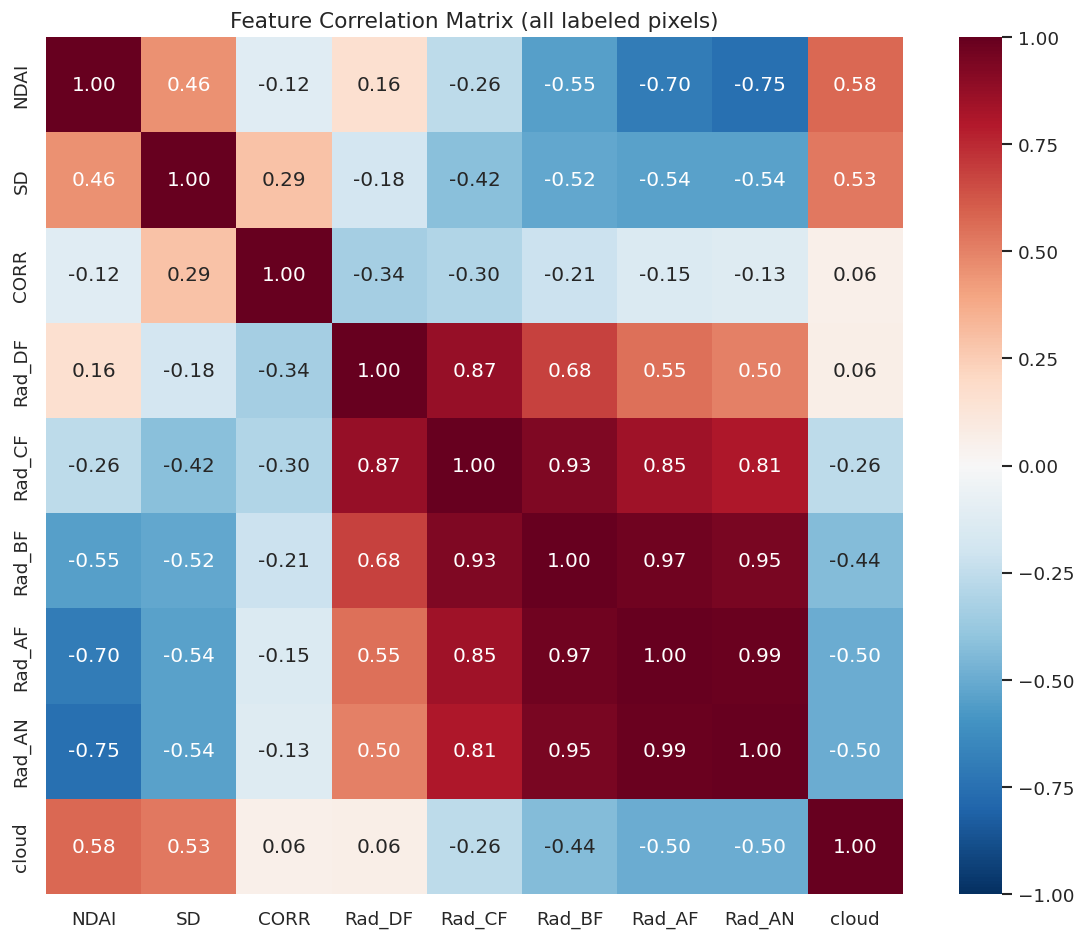

In [19]:
# Full feature correlation heatmap (including cloud label)
fig, ax = plt.subplots(figsize=(10, 8))
corr_all = all_labeled[FEATURE_COLS + ['cloud']].corr()
sns.heatmap(corr_all, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            ax=ax, square=True)
ax.set_title('Feature Correlation Matrix (all labeled pixels)', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Spatial Feature Maps

Visualize how each feature varies spatially across an image, alongside the cloud labels. This reveals whether features capture spatial cloud structure.

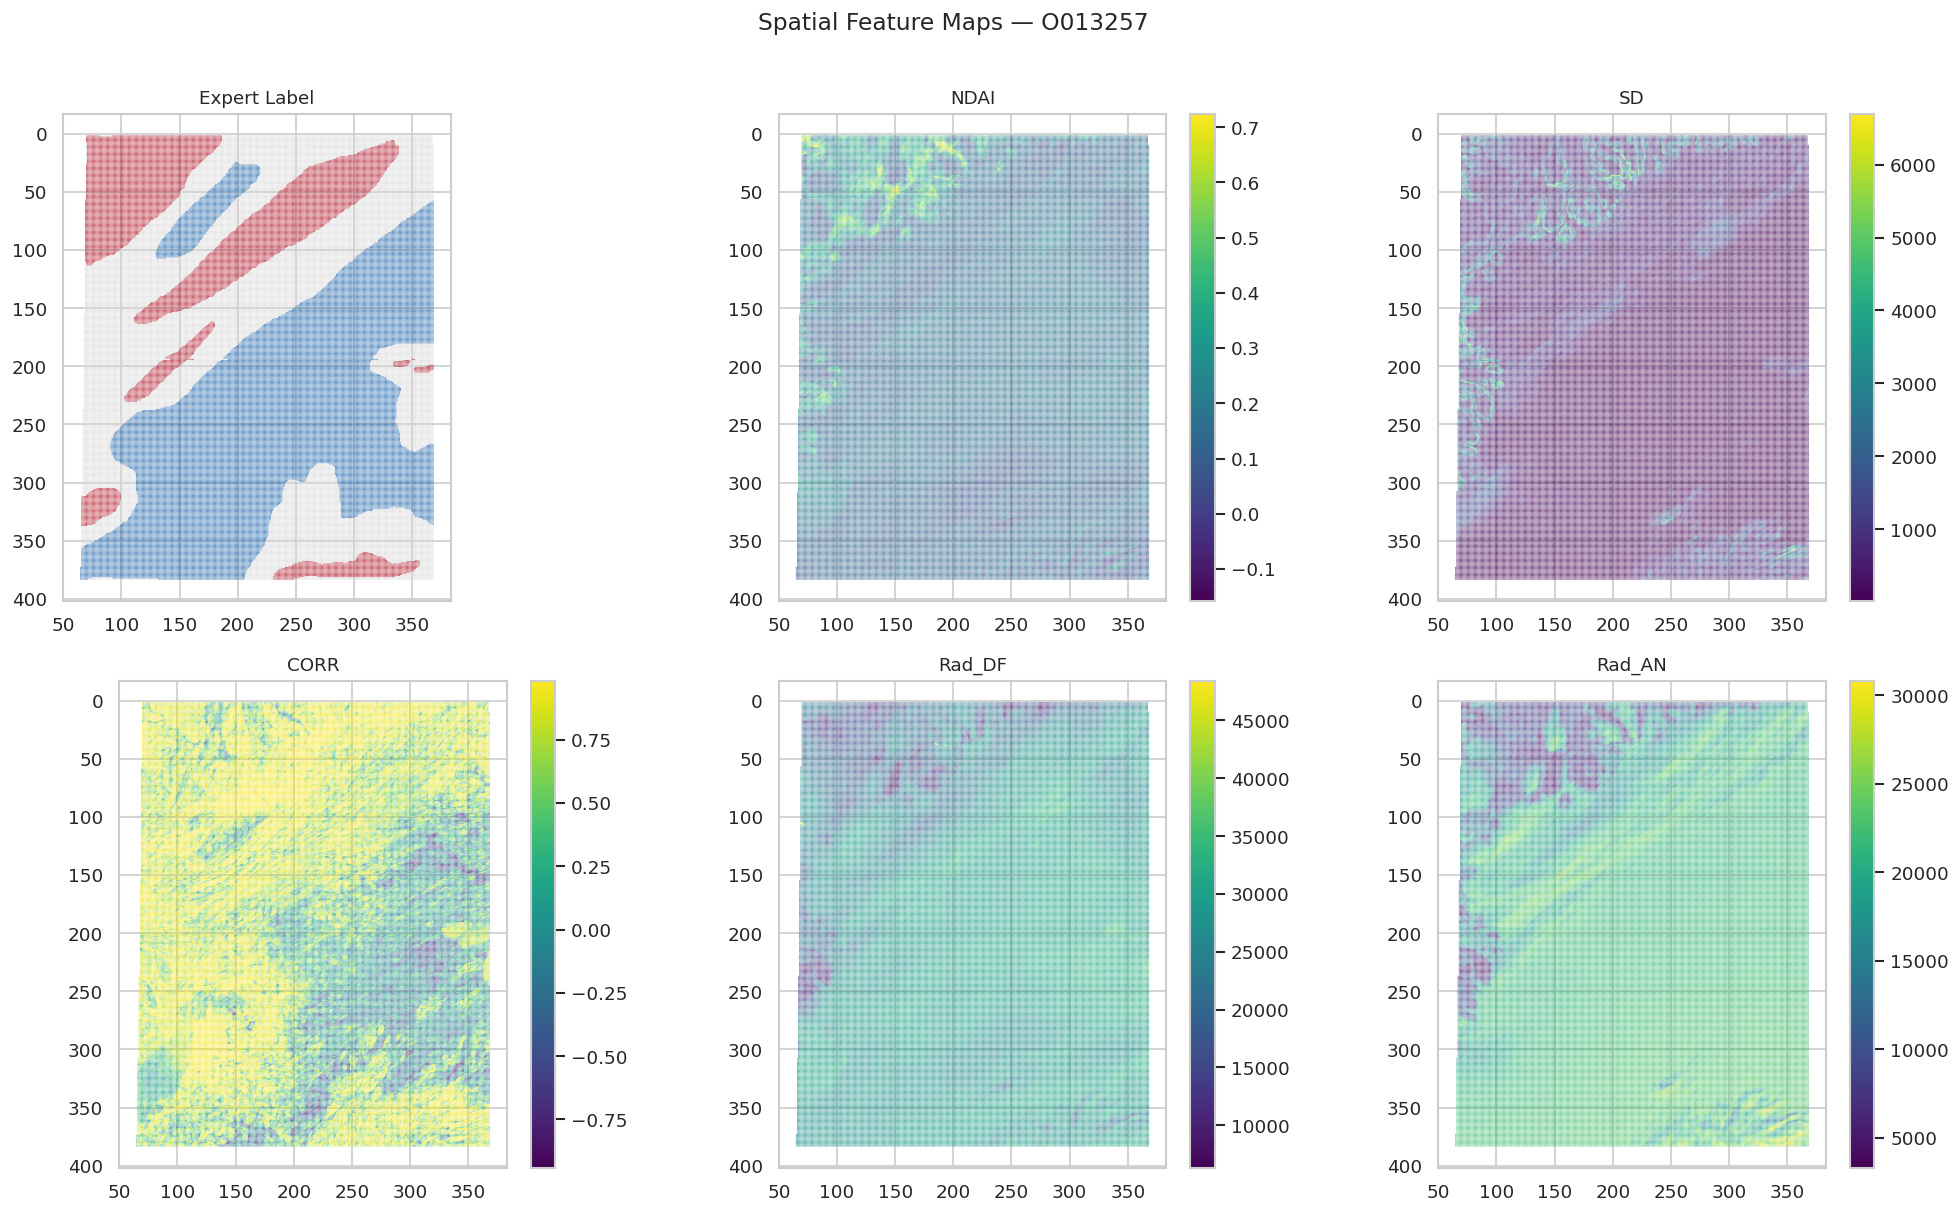

In [20]:
# Spatial feature maps for one image (O013257)
demo_name = 'O013257'
demo_df = dfs[demo_name]  # use full image (including unlabeled) for spatial maps

feats_to_show = ['NDAI', 'SD', 'CORR', 'Rad_DF', 'Rad_AN']
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flat

# First: cloud label map
ax = axes[0]
ax.scatter(demo_df['x'], demo_df['y'], c=demo_df['label'],
           cmap=cmap, norm=norm, s=0.3, edgecolors='none')
ax.set_title('Expert Label', fontsize=11)
ax.set_aspect('equal')
ax.invert_yaxis()

# Then: feature maps
for i, feat in enumerate(feats_to_show):
    ax = axes[i + 1]
    sc = ax.scatter(demo_df['x'], demo_df['y'], c=demo_df[feat],
                    cmap='viridis', s=0.3, edgecolors='none')
    ax.set_title(feat, fontsize=11)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f'Spatial Feature Maps — {demo_name}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 9. Train / Validation / Test Split

**Strategy:** Split **by image** rather than by random pixel. This is critical because:
- Pixels within the same image are spatially correlated
- In real-world deployment, the model will predict on entirely new images
- Splitting by image tests generalization to unseen spatial regions

We use:
- **Image 1 (O013257)** + **Image 2 (O013490)**: Training & Validation (random 80/20 split within)
- **Image 3 (O012791)**: Held-out Test set

This simulates the real scenario where we apply our model to a new, unseen image.

Training set:   122327 pixels  (cloud: 39.1%)
Validation set:  30582 pixels  (cloud: 39.1%)
Test set:        54772 pixels  (cloud: 38.8%)

Total labeled pixels used: 207681


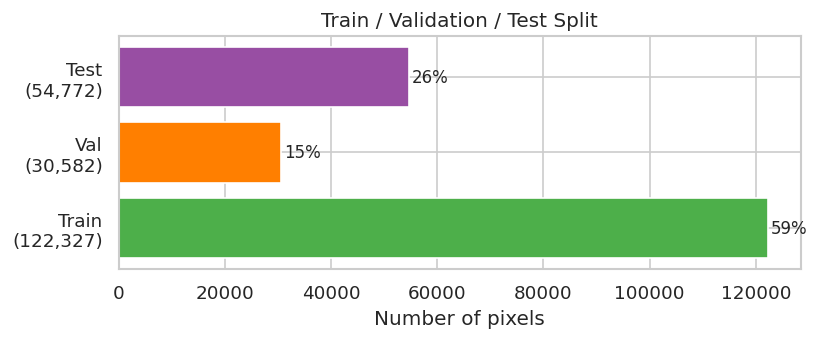

In [21]:
# Train/Val/Test split — by image
# Training + Validation: O013257 + O013490
# Test: O012791
train_val = pd.concat([dfs_labeled['O013257'], dfs_labeled['O013490']], ignore_index=True)
test = dfs_labeled['O012791'].copy()

# Within train_val, do 80/20 random split for train/val
train, val = train_test_split(train_val, test_size=0.2, random_state=42,
                              stratify=train_val['cloud'])

print(f"Training set:   {len(train):>6} pixels  "
      f"(cloud: {train['cloud'].mean():.1%})")
print(f"Validation set: {len(val):>6} pixels  "
      f"(cloud: {val['cloud'].mean():.1%})")
print(f"Test set:       {len(test):>6} pixels  "
      f"(cloud: {test['cloud'].mean():.1%})")
print(f"\nTotal labeled pixels used: {len(train) + len(val) + len(test)}")

# Visualize the split sizes
fig, ax = plt.subplots(figsize=(7, 3))
sizes = [len(train), len(val), len(test)]
labels_split = [f'Train\n({sizes[0]:,})', f'Val\n({sizes[1]:,})', f'Test\n({sizes[2]:,})']
bars = ax.barh(labels_split, sizes, color=['#4daf4a', '#ff7f00', '#984ea3'])
ax.set_xlabel('Number of pixels')
ax.set_title('Train / Validation / Test Split')
for bar, s in zip(bars, sizes):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{s/sum(sizes):.0%}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 10. Summary of Key Findings

Run this cell after executing the notebook to record your observations.

In [22]:
# Summary statistics
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)
print("\n3 labeled images, 164 total images")
print("Each image: ~115,000 pixels × 10 features + coordinates")
print("No NaN or Inf values found in any image")
print()
print("Label distribution across 3 labeled images:")
for name, df in dfs_labeled.items():
    n = len(df)
    nc = df['cloud'].sum()
    print(f"  {name}: {n:>6} labeled pixels, "
          f"cloud={nc} ({100*nc/n:.1f}%), not-cloud={n-nc} ({100*(n-nc)/n:.1f}%)")
print()
print("Feature discriminative power (|standardized Δ| between classes):")
print(importance[['Feature', '|Standardized Δ|']].to_string(index=False))
print()
print("Split strategy: by image (train+val: O013257+O013490, test: O012791)")
print(f"  Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

EDA SUMMARY

3 labeled images, 164 total images
Each image: ~115,000 pixels × 10 features + coordinates
No NaN or Inf values found in any image

Label distribution across 3 labeled images:
  O012791:  54772 labeled pixels, cloud=21244 (38.8%), not-cloud=33528 (61.2%)
  O013257:  70826 labeled pixels, cloud=20468 (28.9%), not-cloud=50358 (71.1%)
  O013490:  82083 labeled pixels, cloud=39253 (47.8%), not-cloud=42830 (52.2%)

Feature discriminative power (|standardized Δ| between classes):
Feature  |Standardized Δ|
   NDAI          1.184013
     SD          1.085599
 Rad_AF          1.018274
 Rad_AN          1.016263
 Rad_BF          0.894415
 Rad_CF          0.533375
 Rad_DF          0.128503
   CORR          0.113966

Split strategy: by image (train+val: O013257+O013490, test: O012791)
  Train: 122327, Val: 30582, Test: 54772


## 11. Feature Engineering

Idea: Both the paper and our EDA support the idea that very high correlations among radiance measurements by angle should be strong indicators of "no cloud", but the CORR variable doesn't seem to capture that. Can we create our own correlation variable that does?

### Attempt 1: Mean Rank Difference

Suppose we have highly correlated radiance measurements, so that their ranks are all very similar. Then we'd like this feature to have a small value. Similarly, if their ranks are dissimilar, then we'd like this feature to have a large value. In its current form, it won't consider surrounding pixels, but let's use this as a starting point for now.

In [23]:
feature_engineering_dfs = dfs.copy()
feature_engineering_dfs = feature_engineering.apply_feat_all_images(feature_engineering_dfs, feature_engineering.rank_difference, 'rank_difference')

### Attempt 2: Pooled Rank Difference

Idea: We also want to account for the fact that nearby pixels are correlated with each other. So let's see if we can apply the `rank_difference` function to all pixels. Then, let's apply them to "patches", either of variable size (ex: 3x3, 5x5, 9x9, etc.). If the patches themselves have strong correlations within the patch, then it is likely the entire patch is not a cloud (or at least that's the hope).

In [24]:
feature_engineering_dfs = feature_engineering.apply_feat_all_images(feature_engineering_dfs, feature_engineering.pooled_rank_difference, 'pooled_rank_difference')

In [25]:
# Evalute features on an image
feature_engineering_dfs_cleaned = clean.remove_unlabeled(feature_engineering_dfs)
feature_engineering_df = clean.combine_labeled(feature_engineering_dfs_cleaned)

print(f"Correlation between rank diff and cloud: {feature_engineering_df['rank_difference'].corr(feature_engineering_df['cloud'])}")
print(f"Correlation between pooled rank diff and cloud: {feature_engineering_df['pooled_rank_difference'].corr(feature_engineering_df['cloud'])}")

Correlation between rank diff and cloud: 0.15402617067508992
Correlation between pooled rank diff and cloud: 0.37947249667153987


Based on the above, it seems like these are pretty good features (better than CORR but perhaps not as good as some of the others. Let's see how they relate to the original features.

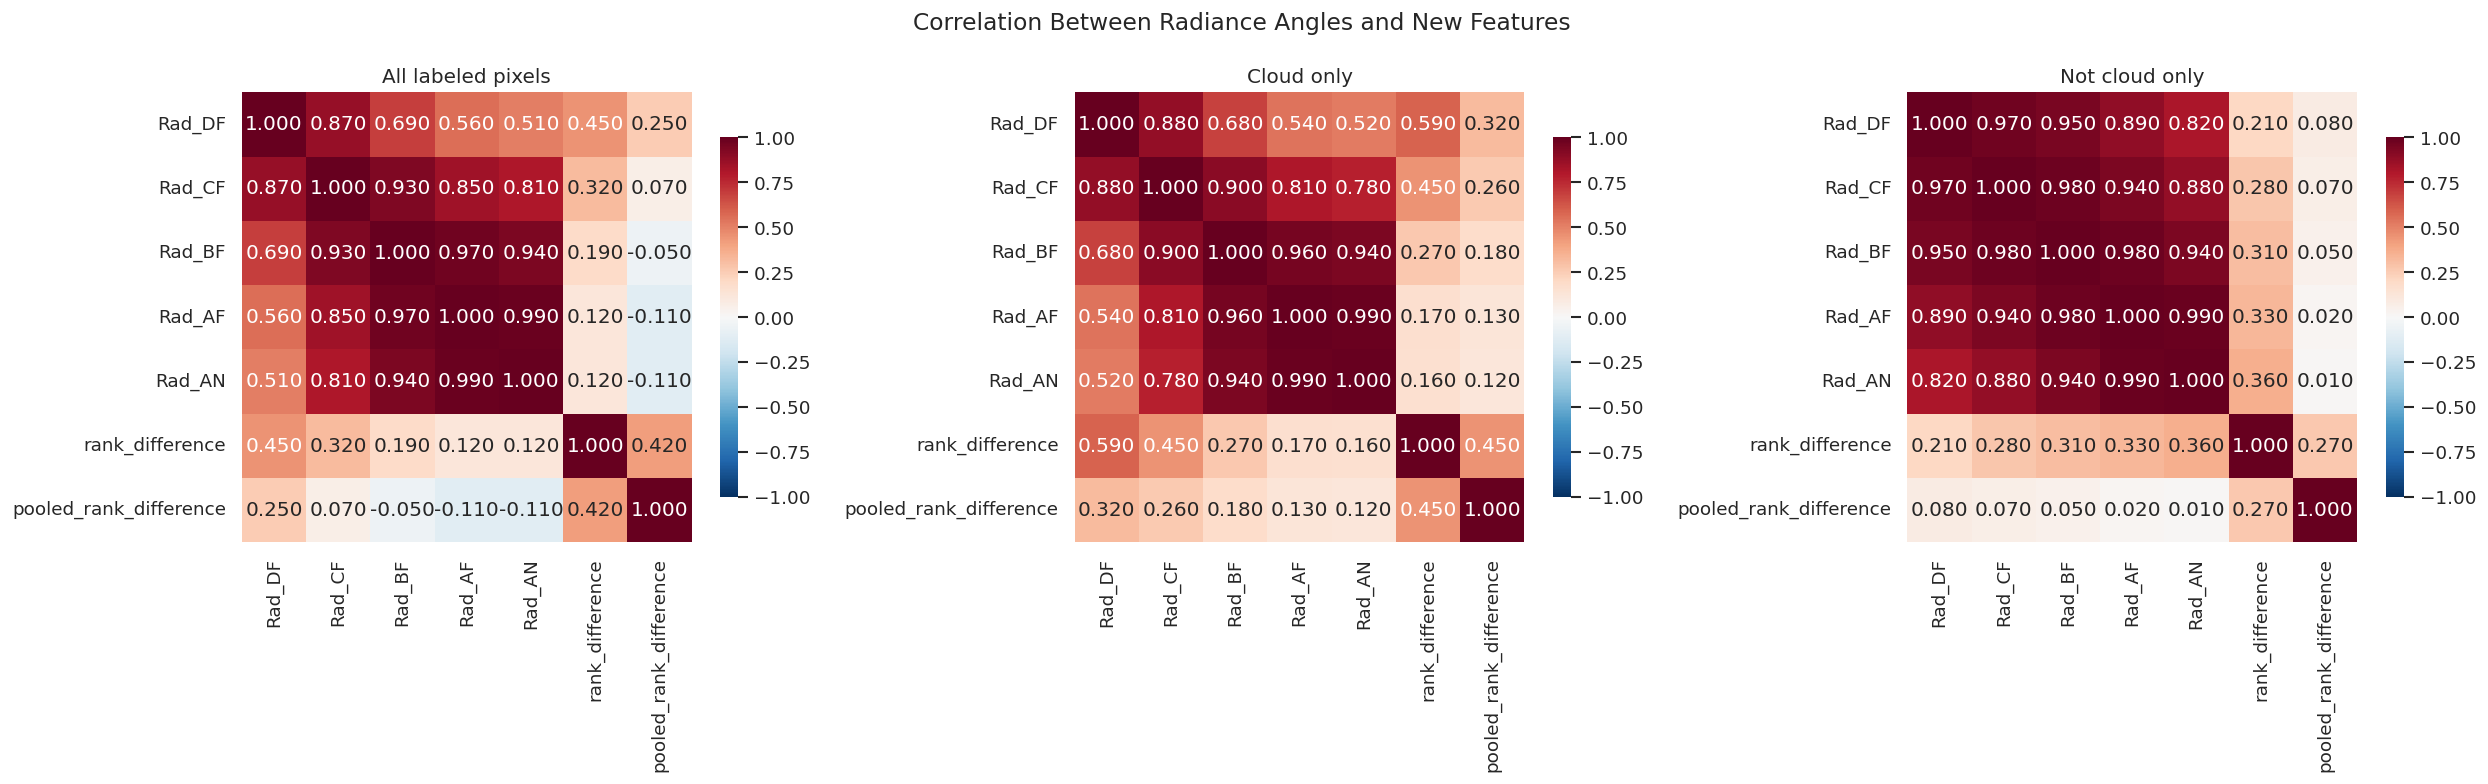

In [26]:
# Correlation heatmap of radiance angles — overall and per class
radiance_feats = ['Rad_DF', 'Rad_CF', 'Rad_BF', 'Rad_AF', 'Rad_AN']
more_radiance_feats = radiance_feats.extend(['rank_difference', 'pooled_rank_difference'])

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (title, subset) in zip(axes, [
    ('All labeled pixels', feature_engineering_df[radiance_feats]),
    ('Cloud only', feature_engineering_df[feature_engineering_df['cloud'] == 1][radiance_feats]),
    ('Not cloud only', feature_engineering_df[feature_engineering_df['cloud'] == 0][radiance_feats]),
]):
    corr = subset.corr().round(2)
    sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', vmin=-1, vmax=1,
                ax=ax, square=True, cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=12)

fig.suptitle('Correlation Between Radiance Angles and New Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

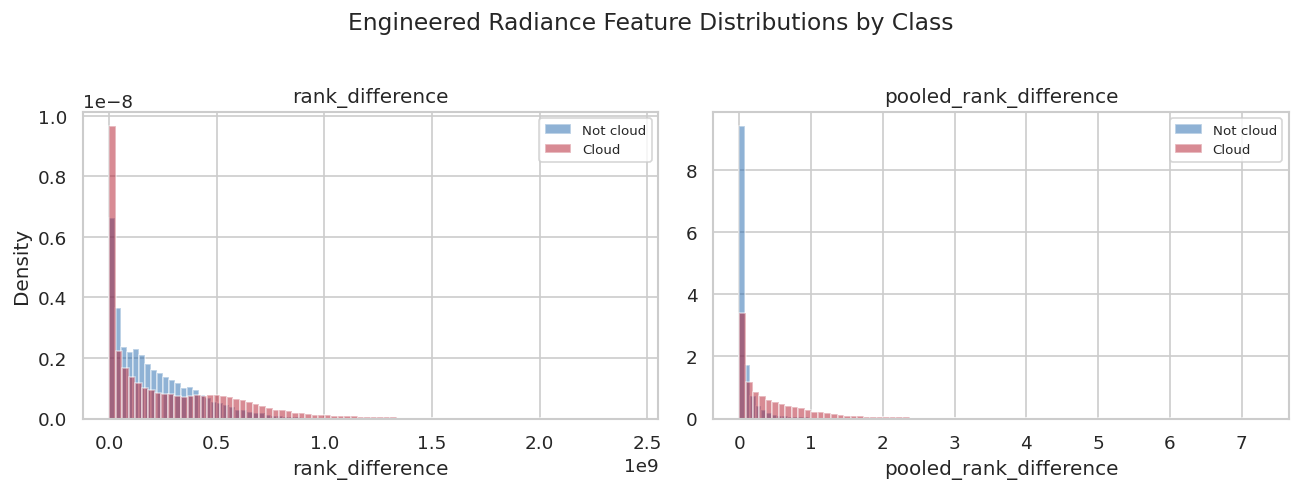

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, feat in zip(axes, ['rank_difference', 'pooled_rank_difference']):
    for cls, color, label in [(0, '#2166ac', 'Not cloud'), (1, '#b2182b', 'Cloud')]:
        subset = feature_engineering_df[feature_engineering_df['cloud'] == cls][feat]
        ax.hist(subset, bins=80, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(feat, fontsize=12)
    ax.set_xlabel(feat)
    if ax == axes[0]:
        ax.set_ylabel('Density')
    ax.legend(fontsize=8)

fig.suptitle('Engineered Radiance Feature Distributions by Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Based on the above analysis, it seems like the idea is solid. I feel like changing the L1/L2 norm or going from rank to z-score might give slight improvements, but that's something I can look at later. For now, I want to look at the effect of averaging other variables.

### Attempt 3: Pooling other variables

So far, we've had some success with

1. Implementing a better CORR variable and
2. Pooling the radiance measurements based on patches of the data.

Let's see if we can pool the other variables.

In [28]:
feature_engineering_dfs = feature_engineering.create_many_transforms(feature_engineering_dfs)
feature_engineering_dfs = feature_engineering.create_many_transforms(feature_engineering_dfs, patch_size=15)
# Also try with smaller patch sizes
# Found that 9x9 works the best for now...
#feature_engineering_dfs = feature_engineering.create_many_transforms(feature_engineering_dfs, patch_size=5)
#feature_engineering_dfs = feature_engineering.create_many_transforms(feature_engineering_dfs, patch_size=3)

### Attempt 4: Gradient of key features:

In image processing, the gradient of an image can be useful for edge detection. It's possible that we can use the edges of features as a feature for determining if a region is a cloud or not. Let's try the Sobel operator (since it's one of the two that I've actually implemented...)

In [29]:
for feat in FEATURE_COLS:
    feature_engineering_dfs = feature_engineering.apply_feat_all_images(
        feature_engineering_dfs, feature_engineering.sobel_gradient, 'sobel_' + feat, feat)

### Other Features

Let's add the other features that were created.

In [30]:
feature_engineering_dfs = feature_engineering.build_features_for_all_dfs(feature_engineering_dfs)

### Evaluation

Now, let's see how these features do. Let's use the `importance` df structure that was above.

In [31]:
feature_engineering_dfs_cleaned = clean.remove_unlabeled(feature_engineering_dfs)
feature_engineering_df = clean.combine_labeled(feature_engineering_dfs_cleaned)

cloud = feature_engineering_df[feature_engineering_df['cloud'] == 1]
no_cloud = feature_engineering_df[feature_engineering_df['cloud'] == 0]

In [32]:
all_columns = [f for f in feature_engineering_df.columns.tolist() if f not in ['cloud', 'x', 'y', 'image', 'label']]

importance = pd.DataFrame({
    'Feature': all_columns,
    'Corr with cloud': [feature_engineering_df[f].corr(feature_engineering_df['cloud']) for f in all_columns],
    'Mean (cloud)': [cloud[f].mean() for f in all_columns],
    'Mean (not cloud)': [no_cloud[f].mean() for f in all_columns],
    'Std (pooled)': [feature_engineering_df[f].std() for f in all_columns],
})
importance['|Standardized Δ|'] = abs(importance['Mean (cloud)'] - importance['Mean (not cloud)']) / importance['Std (pooled)']
importance = importance.sort_values('|Standardized Δ|', ascending=False)

print("Feature Discriminative Power (sorted by standardized mean difference):\n")
print(importance[['Feature', 'Corr with cloud', '|Standardized Δ|']].to_string(index=False))

Feature Discriminative Power (sorted by standardized mean difference):

               Feature  Corr with cloud  |Standardized Δ|
                SD_log         0.760006          1.558290
          NDAI_x_SDlog         0.657084          1.347262
     NDAI_mean_patch15         0.603862          1.238137
      NDAI_mean_patch9         0.596390          1.222818
       SD_mean_patch15         0.593893          1.217698
        SD_mean_patch9         0.575784          1.180568
           aniso_DF_AN         0.567920          1.164444
                  NDAI         0.567920          1.164444
       NDAI_sd_patch15         0.555720          1.139430
        NDAI_sd_patch9         0.531142          1.089036
           ratio_DF_CF         0.495582          1.016124
                    SD         0.495468          1.015891
                Rad_AF        -0.491013          1.006755
                Rad_AN        -0.489757          1.004181
           aniso_CF_AN         0.469268          0.962172


It looks like the 9x9 patches generally tend to perform better than 5x5, then 3x3. This could use a stability check but it's a judgement call that we'll just document for later.

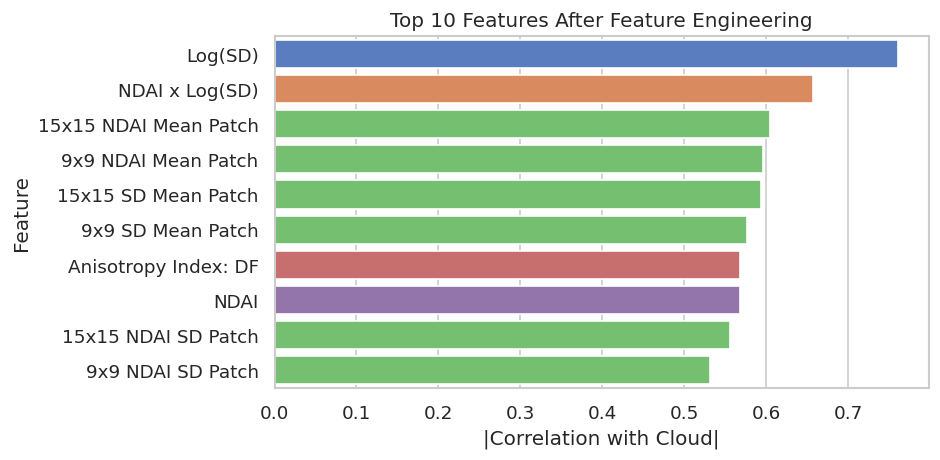

In [38]:
top_10_features = importance.iloc[:10, :]
top_10_names = ['Log(SD)', 'NDAI x Log(SD)', '15x15 NDAI Mean Patch', '9x9 NDAI Mean Patch', '15x15 SD Mean Patch',
                '9x9 SD Mean Patch', 'Anisotropy Index: DF', 'NDAI', '15x15 NDAI SD Patch', '9x9 NDAI SD Patch']
top_10_features['Feature'] = top_10_names
top_10_features['|Correlation with Cloud|'] = np.abs(top_10_features['Corr with cloud'])

palette = sns.color_palette("muted", 8)
plot_colors = ([palette[0]] + [palette[1]] + [palette[2]]*4 + [palette[3]] +
              [palette[4]] + [palette[2]] * 2)

color_dict = {x: y for x, y in zip(top_10_names, plot_colors)}

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(top_10_features, x='|Correlation with Cloud|', y='Feature', palette=color_dict)
ax.set_title('Top 10 Features After Feature Engineering')
plt.tight_layout()
plt.savefig('../report/figures/feature_engineering_top_10.png', bbox_inches='tight')
plt.show()

## For Report - Plot Figures

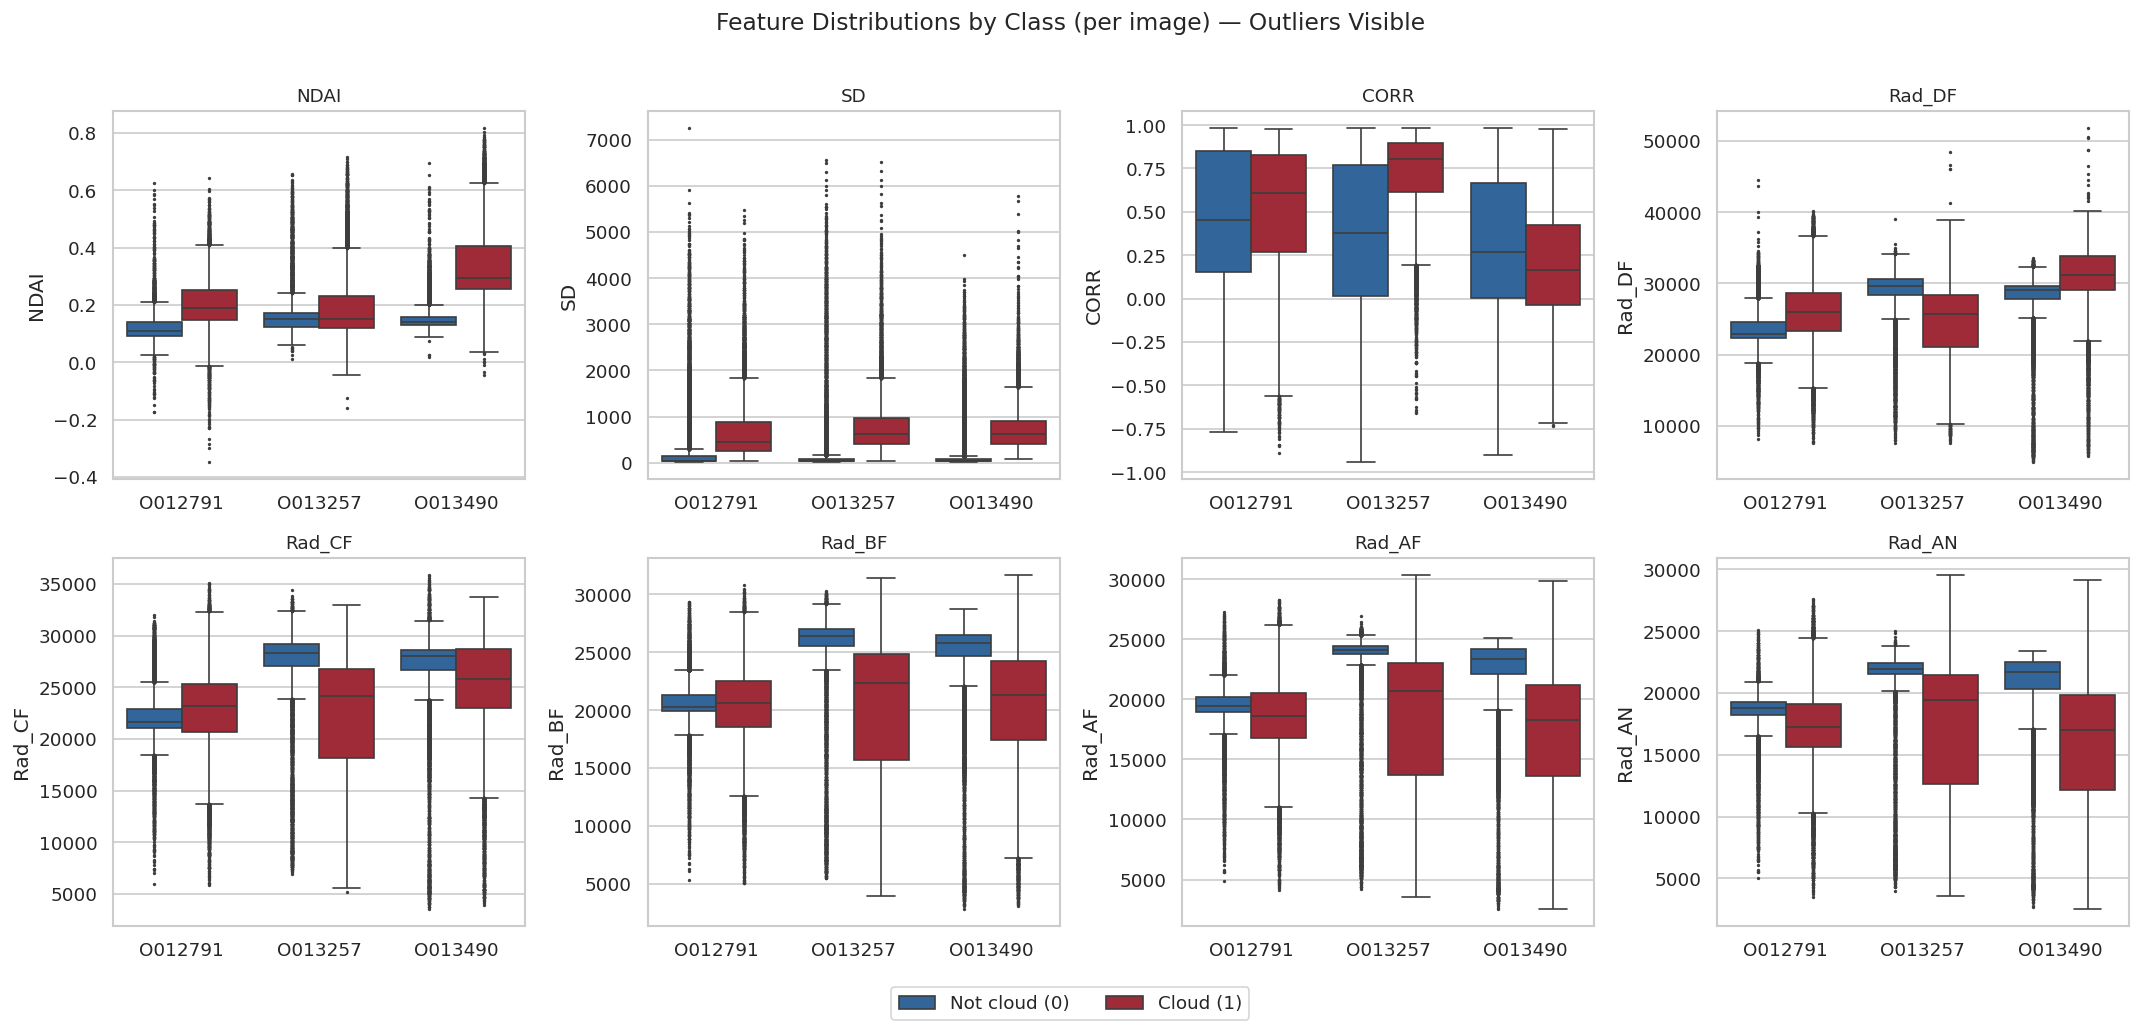

In [34]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, feat in zip(axes.flat, FEATURE_COLS):
    sns.boxplot(data=all_labeled_raw, x='image', y=feat, hue='cloud',
                ax=ax, palette={0: '#2166ac', 1: '#b2182b'}, fliersize=1)
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel('')
    ax.legend([], [], frameon=False)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, ['Not cloud (0)', 'Cloud (1)'], loc='lower center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Feature Distributions by Class (per image) — Outliers Visible', fontsize=14, y=1.01)
plt.tight_layout()
#plt.savefig('../report/figures/feature_boxplots.png', bbox_inches='tight')
plt.show()

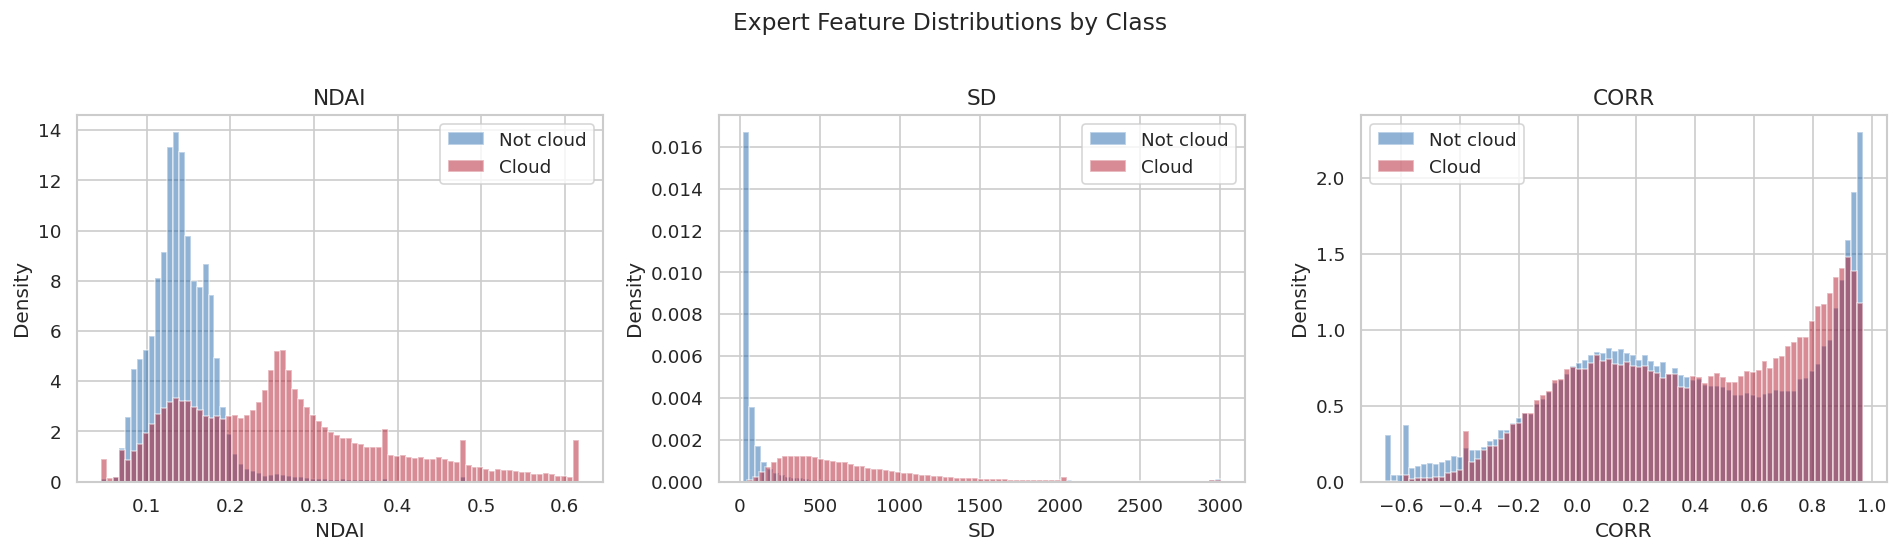

In [35]:
# Histograms of expert features by class (pooled across all 3 images)
expert_feats = ['NDAI', 'SD', 'CORR']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, feat in zip(axes, expert_feats):
    for cls, color, label in [(0, '#2166ac', 'Not cloud'), (1, '#b2182b', 'Cloud')]:
        subset = all_labeled[all_labeled['cloud'] == cls][feat]
        ax.hist(subset, bins=80, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(feat, fontsize=13)
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend()

fig.suptitle('Expert Feature Distributions by Class', fontsize=14, y=1.02)
plt.tight_layout()
#plt.savefig('../report/figures/expert_feature_histograms.png', bbox_inches='tight')
plt.show()